In [1]:
!pip -q install xgboost catboost lightgbm optuna shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.0 MB/s eta 0:00:00


In [2]:
!pip -q install xgboost

import os, glob, zipfile, warnings
import numpy as np
import pandas as pd

from google.colab import files

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

In [3]:
from google.colab import files

print("Upload your GEE ZIP or CSVs + yield CSV")
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("❌ No files uploaded")

print("Uploaded files:", list(uploaded.keys()))

Upload your GEE ZIP or CSVs + yield CSV


Saving drive-download-20260427T224325Z-3-001.zip to drive-download-20260427T224325Z-3-001.zip
Uploaded files: ['drive-download-20260427T224325Z-3-001.zip']


In [4]:
import os, glob, zipfile, shutil

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_files = []
csv_files_uploaded = []

# -----------------------------
# CLASSIFY FILES
# -----------------------------
for filename in uploaded.keys():
    src = os.path.join("/content", filename)

    if filename.lower().endswith(".zip"):
        zip_files.append(src)

    elif filename.lower().endswith(".csv"):
        csv_files_uploaded.append(src)

# -----------------------------
# EXTRACT ZIP FILES
# -----------------------------
for path in zip_files:
    print("Extracting:", os.path.basename(path))
    with zipfile.ZipFile(path, 'r') as z:
        z.extractall(DATA_DIR)

# -----------------------------
# MOVE CSV FILES INTO DATA_DIR
# -----------------------------
for f in csv_files_uploaded:
    dst = os.path.join(DATA_DIR, os.path.basename(f))

    if not os.path.exists(dst):  # avoid overwrite crash
        shutil.move(f, dst)

# -----------------------------
# FIND ALL CSV FILES (FIXED)
# -----------------------------
all_csvs = glob.glob(DATA_DIR + "/**/*.csv", recursive=True)

print("\n✅ Total CSV files found:", len(all_csvs))
for f in all_csvs[:10]:
    print(" -", f)

# -----------------------------
# DEBUG: if still empty
# -----------------------------
if len(all_csvs) == 0:
    print("\n⚠️ No files found in DATA_DIR, checking /content instead...")

    all_csvs = glob.glob("/content/**/*.csv", recursive=True)

    print("Fallback CSV count:", len(all_csvs))
    for f in all_csvs[:10]:
        print(" -", f)

Extracting: drive-download-20260427T224325Z-3-001.zip

✅ Total CSV files found: 13
 - /content/data/Corn_MODIS_lagged_Missouri.csv
 - /content/data/Corn_MODIS_lagged_North_Dakota.csv
 - /content/data/Corn_MODIS_lagged_Kansas.csv
 - /content/data/Corn_MODIS_lagged_Illinois.csv
 - /content/data/Corn_MODIS_lagged_Michigan.csv
 - /content/data/fixed data.csv
 - /content/data/Corn_MODIS_lagged_South_Dakota.csv
 - /content/data/Corn_MODIS_lagged_Minnesota.csv
 - /content/data/Corn_MODIS_lagged_Wisconsin.csv
 - /content/data/Corn_MODIS_lagged_Ohio.csv


In [5]:
# ============================================================
# CELL 1 — FIND SAME-YEAR VS LAGGED-CDL FILES
# Put this directly after all_csvs has been created
# ============================================================

same_year_csvs = [
    f for f in all_csvs
    if "Corn_MODIS" in os.path.basename(f)
    and "lag" not in os.path.basename(f).lower()
    and "prev" not in os.path.basename(f).lower()
]

lagged_csvs = [
    f for f in all_csvs
    if "Corn_MODIS" in os.path.basename(f)
    and (
        "lag" in os.path.basename(f).lower()
        or "prev" in os.path.basename(f).lower()
    )
]

print("==================================================")
print("SAME-YEAR FILES FOUND:", len(same_year_csvs))
print("==================================================")
for f in same_year_csvs[:10]:
    print(os.path.basename(f))

print("\n==================================================")
print("LAGGED-CDL FILES FOUND:", len(lagged_csvs))
print("==================================================")
for f in lagged_csvs[:10]:
    print(os.path.basename(f))

SAME-YEAR FILES FOUND: 0

LAGGED-CDL FILES FOUND: 12
Corn_MODIS_lagged_Missouri.csv
Corn_MODIS_lagged_North_Dakota.csv
Corn_MODIS_lagged_Kansas.csv
Corn_MODIS_lagged_Illinois.csv
Corn_MODIS_lagged_Michigan.csv
Corn_MODIS_lagged_South_Dakota.csv
Corn_MODIS_lagged_Minnesota.csv
Corn_MODIS_lagged_Wisconsin.csv
Corn_MODIS_lagged_Ohio.csv
Corn_MODIS_lagged_Iowa.csv


In [6]:
# ============================================================
# BUILD WIDE GEE FUNCTION (UPDATED FOR NDVI + NDMI + NDWI)
# ============================================================

def build_gee_wide(csv_list):

    dfs = []

    # ✅ UPDATED INDICES
    veg_cols = [
        "NDVI",
        "EVI_scaled",
        "EVI2",
        "NIRv",
        "GCI",
        "NDMI",
        "NDWI"
    ]

    for f in csv_list:

        print("Loading:", os.path.basename(f))

        df = pd.read_csv(f, low_memory=False)
        df.columns = [c.strip() for c in df.columns]

        # ✅ REMOVE OLD RENAMING (no longer needed)
        # NDVI is already correct
        # NDMI + NDWI already correct

        needed = [
            "NAME",
            "GEOID",
            "STATEFP",
            "date",
            "year",
            "NDVI",
            "EVI_scaled",
            "EVI2",
            "NIRv",
            "GCI",
            "NDMI",
            "NDWI"
        ]

        missing = [c for c in needed if c not in df.columns]

        if len(missing) > 0:
            print(f"Skipping {os.path.basename(f)}")
            print("Missing columns:", missing)
            continue

        df = df[needed].copy()

        df["GEOID"] = df["GEOID"].astype(str).str.zfill(5)
        df["STATEFP"] = pd.to_numeric(df["STATEFP"], errors="coerce")
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["DOY"] = df["date"].dt.dayofyear

        for col in veg_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        dfs.append(df)

    gee_long = pd.concat(dfs, ignore_index=True)

    print("\nRaw long shape:", gee_long.shape)

    dup_mask = gee_long.duplicated(
        subset=["GEOID", "year", "DOY"],
        keep=False
    )

    print("Duplicate GEOID-year-DOY rows:", int(dup_mask.sum()))

    if dup_mask.sum() > 0:

        print("Collapsing duplicates...")

        gee_long = (
            gee_long
            .groupby(
                ["GEOID", "NAME", "STATEFP", "year", "DOY"],
                as_index=False
            )[veg_cols]
            .mean()
        )

    print("Shape after duplicate handling:", gee_long.shape)

    print("\n===== GEE LONG SAMPLE =====")
    display(
        gee_long[
            [
                "GEOID",
                "year",
                "DOY",
                "NDVI",
                "EVI_scaled",
                "EVI2",
                "NIRv",
                "GCI",
                "NDMI",
                "NDWI"
            ]
        ].head(15)
    )

    # ============================================================
    # WIDE FORMAT
    # ============================================================

    wide_parts = []

    for col in veg_cols:

        temp = gee_long.pivot_table(
            index=["GEOID", "year"],
            columns="DOY",
            values=col,
            aggfunc="mean"
        )

        temp.columns = [f"{col}_DOY_{int(c)}" for c in temp.columns]

        wide_parts.append(temp)

    gee_wide = pd.concat(wide_parts, axis=1).reset_index()

    print("\nWide shape:", gee_wide.shape)

    print(
        "Unique county-years:",
        gee_wide[["GEOID", "year"]].drop_duplicates().shape[0]
    )

    print("\n===== GEE WIDE SAMPLE =====")
    display(gee_wide.head())

    return gee_wide

In [7]:
# ============================================================
# CELL 3 — BUILD SAME-YEAR AND LAGGED GEE TABLES
# ============================================================

#same_year_gee_wide = build_gee_wide(same_year_csvs)
lagged_gee_wide = build_gee_wide(lagged_csvs)

print("\n==================================================")
print("FINAL DATASET SHAPES")
print("==================================================")
print#("Same-year GEE shape:", same_year_gee_wide.shape)
print("Lagged-CDL GEE shape:", lagged_gee_wide.shape)

Loading: Corn_MODIS_lagged_Missouri.csv
Loading: Corn_MODIS_lagged_North_Dakota.csv
Loading: Corn_MODIS_lagged_Kansas.csv
Loading: Corn_MODIS_lagged_Illinois.csv
Loading: Corn_MODIS_lagged_Michigan.csv
Loading: Corn_MODIS_lagged_South_Dakota.csv
Loading: Corn_MODIS_lagged_Minnesota.csv
Loading: Corn_MODIS_lagged_Wisconsin.csv
Loading: Corn_MODIS_lagged_Ohio.csv
Loading: Corn_MODIS_lagged_Iowa.csv
Loading: Corn_MODIS_lagged_Nebraska.csv
Loading: Corn_MODIS_lagged_Indiana.csv

Raw long shape: (269025, 13)
Duplicate GEOID-year-DOY rows: 0
Shape after duplicate handling: (269025, 13)

===== GEE LONG SAMPLE =====


,GEOID,year,DOY,NDVI,EVI_scaled,EVI2,NIRv,GCI,NDMI,NDWI
0,29510,2008,65,2885.000000,0.142000,0.140688,0.051221,1.849117,-0.128407,-0.480400
1,29187,2008,65,4137.875000,0.226800,0.226834,0.093624,1.814045,-0.103558,-0.466679
2,29071,2008,65,3303.776886,0.188962,0.186899,0.075688,1.674478,-0.118539,-0.446365
3,29183,2008,65,2967.397610,0.149476,0.145541,0.054971,1.478240,-0.145010,-0.415520
4,29219,2008,65,3345.392894,0.190428,0.187285,0.075831,1.622683,-0.124256,-0.437415
5,29189,2008,65,2888.910604,0.151969,0.149582,0.056945,1.377989,-0.141464,-0.400292
6,29099,2008,65,3177.179013,0.165881,0.168165,0.065487,1.792391,-0.118578,-0.457889
7,29113,2008,65,3380.895219,0.190011,0.186476,0.075192,1.618280,-0.126305,-0.436724
8,29209,2008,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,29213,2008,65,4168.666667,0.235967,0.236030,0.098877,2.324574,-0.031905,-0.536001



Wide shape: (17686, 107)
Unique county-years: 17686

===== GEE WIDE SAMPLE =====


,GEOID,year,NDVI_DOY_65,NDVI_DOY_81,NDVI_DOY_97,NDVI_DOY_113,NDVI_DOY_129,NDVI_DOY_145,NDVI_DOY_161,NDVI_DOY_177,NDVI_DOY_193,NDVI_DOY_209,NDVI_DOY_225,NDVI_DOY_241,NDVI_DOY_257,NDVI_DOY_273,NDVI_DOY_289,EVI_scaled_DOY_65,EVI_scaled_DOY_81,EVI_scaled_DOY_97,EVI_scaled_DOY_113,EVI_scaled_DOY_129,EVI_scaled_DOY_145,EVI_scaled_DOY_161,EVI_scaled_DOY_177,EVI_scaled_DOY_193,EVI_scaled_DOY_209,EVI_scaled_DOY_225,EVI_scaled_DOY_241,EVI_scaled_DOY_257,EVI_scaled_DOY_273,EVI_scaled_DOY_289,EVI2_DOY_65,EVI2_DOY_81,EVI2_DOY_97,EVI2_DOY_113,EVI2_DOY_129,EVI2_DOY_145,EVI2_DOY_161,EVI2_DOY_177,EVI2_DOY_193,EVI2_DOY_209,EVI2_DOY_225,EVI2_DOY_241,EVI2_DOY_257,EVI2_DOY_273,EVI2_DOY_289,NIRv_DOY_65,NIRv_DOY_81,NIRv_DOY_97,NIRv_DOY_113,NIRv_DOY_129,NIRv_DOY_145,NIRv_DOY_161,NIRv_DOY_177,NIRv_DOY_193,NIRv_DOY_209,NIRv_DOY_225,NIRv_DOY_241,NIRv_DOY_257,NIRv_DOY_273,NIRv_DOY_289,GCI_DOY_65,GCI_DOY_81,GCI_DOY_97,GCI_DOY_113,GCI_DOY_129,GCI_DOY_145,GCI_DOY_161,GCI_DOY_177,GCI_DOY_193,GCI_DOY_209,GCI_DOY_225,GCI_DOY_241,GCI_DOY_257,GCI_DOY_273,GCI_DOY_289,NDMI_DOY_65,NDMI_DOY_81,NDMI_DOY_97,NDMI_DOY_113,NDMI_DOY_129,NDMI_DOY_145,NDMI_DOY_161,NDMI_DOY_177,NDMI_DOY_193,NDMI_DOY_209,NDMI_DOY_225,NDMI_DOY_241,NDMI_DOY_257,NDMI_DOY_273,NDMI_DOY_289,NDWI_DOY_65,NDWI_DOY_81,NDWI_DOY_97,NDWI_DOY_113,NDWI_DOY_129,NDWI_DOY_145,NDWI_DOY_161,NDWI_DOY_177,NDWI_DOY_193,NDWI_DOY_209,NDWI_DOY_225,NDWI_DOY_241,NDWI_DOY_257,NDWI_DOY_273,NDWI_DOY_289
0,17001,2008,2643.490034,2756.522594,2977.154298,3683.621552,4229.542452,4320.767129,4812.968693,6232.008603,7077.678094,7540.352397,7754.912162,7878.816598,6944.734413,4770.797513,3970.468196,0.140172,0.157946,0.178791,0.230865,0.245945,0.268355,0.325593,0.434070,0.537808,0.590853,0.608500,0.621077,0.477930,0.291778,0.211301,0.137598,0.155730,0.176198,0.226400,0.240967,0.262718,0.318390,0.426608,0.527235,0.579696,0.597444,0.608347,0.471281,0.293259,0.208828,0.051328,0.060795,0.071772,0.097873,0.103680,0.117007,0.151479,0.217398,0.289584,0.325891,0.336683,0.344734,0.245206,0.135779,0.085738,1.262944,1.384909,1.124750,1.553817,2.049942,2.294790,2.671866,3.483219,4.657210,6.369801,6.751532,6.162032,4.495563,2.513495,1.955019,-0.191060,-0.141108,-0.239877,-0.157833,-0.037053,-0.040717,0.044459,0.151650,0.208430,0.336711,0.324471,0.288337,0.262175,0.031826,-0.083191,-0.382386,-0.397563,-0.351239,-0.427149,-0.490994,-0.516868,-0.554398,-0.591264,-0.621158,-0.705748,-0.715583,-0.699539,-0.646690,-0.520534,-0.476291
1,17001,2009,2524.293525,2745.912546,3019.016051,4041.654356,4371.302555,4642.362082,5555.237304,5842.529637,7970.555452,8749.573520,8741.680743,8371.174209,7525.397576,5501.084075,4127.638774,0.145199,0.164249,0.186793,0.270465,0.295263,0.303172,0.365268,0.433199,0.626153,0.731425,0.739015,0.659977,0.550461,0.359583,0.221582,0.143601,0.162308,0.183881,0.267569,0.288409,0.296567,0.360436,0.426221,0.614981,0.719750,0.726993,0.649183,0.541151,0.364820,0.218698,0.055802,0.065149,0.076183,0.122389,0.134103,0.137871,0.173417,0.219449,0.343807,0.423406,0.429844,0.367722,0.289384,0.176218,0.089907,0.973586,0.792851,1.386608,0.007091,1.860501,2.125543,2.363990,3.073181,5.012006,6.825299,8.312240,6.206209,4.813583,2.954867,1.836573,-0.171836,0.191825,-0.149982,-0.108396,-0.038797,-0.056113,0.061779,0.067651,0.245261,0.338415,0.383773,0.318690,0.250256,0.072681,-0.096046,-0.318333,-0.224925,-0.402287,0.061105,-0.469390,-0.490451,-0.492891,-0.587583,-0.689745,-0.762900,-0.794742,-0.741404,-0.692804,-0.587286,-0.464196
2,17001,2010,2602.040503,2792.352749,3381.078759,4048.869871,4270.290644,4000.306721,6204.925248,6265.538619,7715.329520,8274.215101,8414.656795,7493.336201,6077.688481,4629.270220,3490.902628,0.130884,0.160507,0.225790,0.246040,0.255890,0.275180,0.421254,0.486031,0.592505,0.676585,0.631966,0.574497,0.414203,0.282345,0.210728,0.129658,0.158564,0.222968,0.240707,0.253978,0.271078,0.412799,0.477746,0.583628,0.662853,0.619553,0.562409,0.403198,0.281131,0.210051,0.047550,0.062587,0.098564,0.105600,0.111502,0.125554,0.20


FINAL DATASET SHAPES
Lagged-CDL GEE shape: (17686, 107)


In [8]:
# ============================================================
# CELL 5 — INTERPOLATE LAGGED-CDL DATA
# ============================================================

lagged_cdl_df = lagged_gee_wide.copy()

lagged_cdl_df = lagged_cdl_df.sort_values(
    ["GEOID", "year"]
).reset_index(drop=True)

lagged_feature_cols = [
    c for c in lagged_cdl_df.columns
    if c not in ["GEOID", "year"]
]

lagged_cdl_df[lagged_feature_cols] = (
    lagged_cdl_df
    .groupby("GEOID")[lagged_feature_cols]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit_direction="both"
        )
    )
)

print("Lagged-CDL interpolation complete")
print("Shape:", lagged_cdl_df.shape)

Lagged-CDL interpolation complete
Shape: (17686, 107)


In [9]:
# ============================================================
# FIND YIELD FILE PATH
# Run this BEFORE the yield_df cell
# ============================================================

yield_candidates = [
    f for f in all_csvs
    if "Corn_MODIS" not in os.path.basename(f)
]

print("Possible yield files found:")
for f in yield_candidates:
    print(os.path.basename(f))

YIELD_PATH = yield_candidates[0]

print("\nUsing yield file:")
print(YIELD_PATH)

Possible yield files found:
fixed data.csv

Using yield file:
/content/data/fixed data.csv


In [10]:
# ============================================================
# FIX YIELD_DF NOT FOUND
# Run this BEFORE Cell 6 merge
# ============================================================

yield_raw = pd.read_csv(YIELD_PATH, low_memory=False)
yield_raw.columns = [c.strip() for c in yield_raw.columns]

yield_df = yield_raw.copy()

yield_df = yield_df[
    (yield_df["Geo Level"] == "COUNTY") &
    (yield_df["Commodity"] == "CORN") &
    (yield_df["Data Item"] == "CORN, GRAIN - YIELD, MEASURED IN BU / ACRE") &
    (yield_df["Period"] == "YEAR") &
    (yield_df["Domain"] == "TOTAL")
].copy()

yield_df = yield_df[
    yield_df["State ANSI"].notna() &
    yield_df["County ANSI"].notna()
].copy()

yield_df["STATEFP"] = pd.to_numeric(
    yield_df["State ANSI"],
    errors="coerce"
).astype(int)

yield_df["COUNTYFP"] = pd.to_numeric(
    yield_df["County ANSI"],
    errors="coerce"
).astype(int)

yield_df["year"] = pd.to_numeric(
    yield_df["Year"],
    errors="coerce"
).astype(int)

yield_df["yield_bu_acre"] = pd.to_numeric(
    yield_df["Value"],
    errors="coerce"
)

yield_df["GEOID"] = (
    yield_df["STATEFP"].astype(str).str.zfill(2) +
    yield_df["COUNTYFP"].astype(str).str.zfill(3)
)

yield_df = yield_df[
    ["GEOID", "year", "yield_bu_acre"]
].drop_duplicates()

print("Yield dataframe shape:", yield_df.shape)
print("Yield years:", yield_df["year"].min(), "to", yield_df["year"].max())
print("Yield counties:", yield_df["GEOID"].nunique())

Yield dataframe shape: (25659, 3)
Yield years: 2008 to 2024
Yield counties: 2143


In [11]:
# ============================================================
# CELL 6 — MERGE YIELD INTO BOTH DATASETS
# Replace your old model_df merge cell with this
# ============================================================

#same_year_df = same_year_df.merge(
 #   yield_df[["GEOID", "year", "yield_bu_acre"]],
  #  on=["GEOID", "year"],
   # how="inner",
    #validate="one_to_one"
#)

lagged_cdl_df = lagged_cdl_df.merge(
    yield_df[["GEOID", "year", "yield_bu_acre"]],
    on=["GEOID", "year"],
    how="inner",
    validate="one_to_one"
)

#print("Same-year merged shape:", same_year_df.shape)
print("Lagged merged shape:", lagged_cdl_df.shape)

Lagged merged shape: (14211, 108)


In [12]:
# ============================================================
# CELL 7 — BUILD HISTORICAL FEATURES (FIXED + hist_3yr ADDED)
# ============================================================

for temp_df in [lagged_cdl_df]:

    # ------------------------------------------------
    # SORT (VERY IMPORTANT for rolling correctness)
    # ------------------------------------------------
    temp_df.sort_values(["GEOID", "year"], inplace=True)

    # ------------------------------------------------
    # 5-YEAR HISTORICAL AVERAGE (baseline)
    # ------------------------------------------------
    temp_df["hist_5yr"] = (
        temp_df.groupby("GEOID")["yield_bu_acre"]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

    # ------------------------------------------------
    # 🔥 NEW: 3-YEAR HISTORICAL AVERAGE (short-term)
    # ------------------------------------------------
    temp_df["hist_3yr"] = (
        temp_df.groupby("GEOID")["yield_bu_acre"]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

    # ------------------------------------------------
    # FILL YIELD VALUES (used for training stability)
    # ------------------------------------------------
    temp_df["yield_filled"] = temp_df["yield_bu_acre"]

    missing_mask = temp_df["yield_filled"].isna()

    temp_df.loc[missing_mask, "yield_filled"] = temp_df.loc[
        missing_mask, "hist_5yr"
    ]

    temp_df["yield_filled"] = temp_df["yield_filled"].fillna(
        temp_df["yield_bu_acre"].median()
    )

    # ------------------------------------------------
    # ANOMALY TARGET (based on 5yr baseline)
    # ------------------------------------------------
    temp_df["yield_anomaly"] = (
        temp_df["yield_bu_acre"] - temp_df["hist_5yr"]
    )

print("Historical features (hist_5yr, hist_3yr, anomaly) created")

Historical features (hist_5yr, hist_3yr, anomaly) created


In [13]:
# ============================================================
# CELL 8 — CREATE ANOMALY FEATURES (FIXED)
# ============================================================

veg_indices = [
    "NDVI",
    "EVI_scaled",
    "EVI2",
    "NDMI",
    "NDWI",
    "NIRv",
    "GCI"
]

for temp_df in [ lagged_cdl_df]:

    for idx in veg_indices:

        idx_cols = [
            c for c in temp_df.columns
            if c.startswith(idx + "_DOY_")
            and not c.endswith("_anom")
        ]

        if len(idx_cols) == 0:
            print(f"⚠️ No columns found for {idx}")
            continue

        for col in idx_cols:

            # ------------------------------------------------
            # HISTORICAL MEAN (NO LEAKAGE)
            # ------------------------------------------------
            hist_mean = (
                temp_df.groupby("GEOID")[col]
                .transform(lambda x: x.shift(1).expanding().mean())
            )

            # ------------------------------------------------
            # ANOMALY
            # ------------------------------------------------
            temp_df[col + "_anom"] = temp_df[col] - hist_mean

print("✅ Vegetation anomaly features created")

✅ Vegetation anomaly features created


In [14]:
# ============================================================
# CELL 9 — DROP ROWS WITHOUT HISTORICAL INFORMATION
# ============================================================

#same_year_df = same_year_df[
#    same_year_df["hist_5yr"].notna()
#].copy()

lagged_cdl_df = lagged_cdl_df[
    lagged_cdl_df["hist_5yr"].notna()
].copy()

#print("Same-year rows:", len(same_year_df))
print("Lagged rows:", len(lagged_cdl_df))

Lagged rows: 13198


In [15]:
def build_features(df_sub, doy_cut):

    feature_list = []

    veg_indices = [
        "NDVI",
        "EVI_scaled",
        "EVI2",
        "NDMI",
        "NDWI",
        "NIRv",
        "GCI"
    ]

    for idx in veg_indices:

        # ====================================================
        # RAW DOY FEATURES
        # ====================================================
        raw_cols = [
            c for c in df_sub.columns
            if c.startswith(idx + "_DOY_")
            and not c.endswith("_anom")
        ]

        raw_cols = [
            c for c in raw_cols
            if int(c.split("_DOY_")[-1]) <= doy_cut
        ]

        raw_cols = sorted(
            raw_cols,
            key=lambda x: int(x.split("_DOY_")[-1])
        )

        # -----------------------------
        # ADD RAW FEATURES DIRECTLY
        # -----------------------------
        if len(raw_cols) > 0:
            feature_list.append(df_sub[raw_cols])

        # -----------------------------
        # AGGREGATED FEATURES
        # -----------------------------
        if len(raw_cols) > 0:

            X = df_sub[raw_cols].values
            feat_df = pd.DataFrame(index=df_sub.index)

            feat_df[f"{idx}_mean"] = np.nanmean(X, axis=1)
            feat_df[f"{idx}_max"] = np.nanmax(X, axis=1)
            feat_df[f"{idx}_min"] = np.nanmin(X, axis=1)
            feat_df[f"{idx}_std"] = np.nanstd(X, axis=1)
            feat_df[f"{idx}_last"] = X[:, -1]
            feat_df[f"{idx}_auc"] = np.nansum(X, axis=1)

            if X.shape[1] >= 3:
                feat_df[f"{idx}_early_mean"] = np.nanmean(
                    X[:, :3], axis=1
                )

            if X.shape[1] >= 2:
                feat_df[f"{idx}_slope"] = (
                    X[:, -1] - X[:, -2]
                )

            feature_list.append(feat_df)

        # ====================================================
        # ANOMALY FEATURES
        # ====================================================
        anom_cols = [
            c for c in df_sub.columns
            if c.startswith(idx + "_DOY_")
            and c.endswith("_anom")
        ]

        anom_cols = [
            c for c in anom_cols
            if int(c.split("_DOY_")[-1].replace("_anom", "")) <= doy_cut
        ]

        anom_cols = sorted(
            anom_cols,
            key=lambda x: int(
                x.split("_DOY_")[-1].replace("_anom", "")
            )
        )

        if len(anom_cols) > 0:

            X_anom = df_sub[anom_cols].values
            feat_df_anom = pd.DataFrame(index=df_sub.index)

            feat_df_anom[f"{idx}_anom_mean"] = np.nanmean(X_anom, axis=1)
            feat_df_anom[f"{idx}_anom_max"] = np.nanmax(X_anom, axis=1)
            feat_df_anom[f"{idx}_anom_min"] = np.nanmin(X_anom, axis=1)
            feat_df_anom[f"{idx}_anom_last"] = X_anom[:, -1]

            if X_anom.shape[1] >= 2:
                feat_df_anom[f"{idx}_anom_slope"] = (
                    X_anom[:, -1] - X_anom[:, -2]
                )

            feature_list.append(feat_df_anom)

    # ====================================================
    # FINAL CONCAT
    # ====================================================
    if len(feature_list) == 0:
        return pd.DataFrame(index=df_sub.index)

    return pd.concat(feature_list, axis=1)

In [16]:
# ============================================================
# CREATE MODEL-READY COPIES
# ============================================================

#df_same_cdl = same_year_df.copy()
df_prev_cdl = lagged_cdl_df.copy()

#print("df_same_cdl shape:", df_same_cdl.shape)
print("df_prev_cdl shape:", df_prev_cdl.shape)

df_prev_cdl shape: (13198, 217)


In [17]:
# ============================================================
# BUILD TWO MODEL-READY DATAFRAMES
# Run this AFTER df_same_cdl and df_prev_cdl already exist
# ============================================================

#print("Same-year dataframe shape:", df_same_cdl.shape)
print("Previous-year dataframe shape:", df_prev_cdl.shape)

#print("\nExample same-year columns:")
#print([c for c in df_same_cdl.columns if "EVI2_DOY" in c][:5])

print("\nExample previous-year columns:")
print([c for c in df_prev_cdl.columns if "EVI2_DOY" in c][:5])

Previous-year dataframe shape: (13198, 217)

Example previous-year columns:
['EVI2_DOY_65', 'EVI2_DOY_81', 'EVI2_DOY_97', 'EVI2_DOY_113', 'EVI2_DOY_129']


In [18]:
# ============================================================
# DIRECT YIELD MODEL — CATBOOST
# Train: df_prev_cdl
# Test:  df_prev_cdl
# ============================================================

from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

TEST_YEARS = list(range(2018, 2025))

results_direct = []
feature_importance_direct_rows = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # -----------------------------
        # TRAIN + TEST
        # -----------------------------
        train_df = df_prev_cdl[df_prev_cdl["year"] < yr].copy()
        test_df  = df_prev_cdl[df_prev_cdl["year"] == yr].copy()

        X_train = build_features(train_df, doy_cut)
        X_test  = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # -----------------------------
        # REMOVE LEAKAGE
        # -----------------------------
        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(columns=[c for c in leakage_cols if c in X_train.columns], errors="ignore")
        X_test  = X_test.drop(columns=[c for c in leakage_cols if c in X_test.columns], errors="ignore")

        # -----------------------------
        # ADD SAFE FEATURES
        # -----------------------------
        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"]  = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"]  = test_df.loc[X_test.index, "year"]

        # -----------------------------
        # FILL NA
        # -----------------------------
        medians = X_train.median()
        X_train = X_train.fillna(medians)
        X_test  = X_test.fillna(medians)

        # -----------------------------
        # TARGET
        # -----------------------------
        y_train = train_df.loc[X_train.index, "yield_filled"]
        y_test_actual = test_df.loc[X_test.index, "yield_bu_acre"].values

        # -----------------------------
        # CATBOOST MODEL
        # -----------------------------
        model = CatBoostRegressor(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            loss_function='RMSE',
            random_seed=42,
            verbose=0
        )

        model.fit(X_train, y_train)

        # -----------------------------
        # FEATURE IMPORTANCE
        # -----------------------------
        importance_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.get_feature_importance(),
            "year": yr,
            "DOY": doy_cut,
            "model": "catboost"
        })

        feature_importance_direct_rows.append(importance_df)

        # -----------------------------
        # PREDICT
        # -----------------------------
        pred_yield = model.predict(X_test)

        # -----------------------------
        # METRICS
        # -----------------------------
        r2 = r2_score(y_test_actual, pred_yield)
        rmse = np.sqrt(mean_squared_error(y_test_actual, pred_yield))

        results_direct.append({
            "year": yr,
            "DOY": doy_cut,
            "R2": r2,
            "RMSE": rmse
        })

        print(f"[CATBOOST] Year {yr} | DOY {doy_cut} | R² = {r2:.3f}")

# ============================================================
# FINAL DATAFRAMES
# ============================================================

results_direct_df = pd.DataFrame(results_direct)

summary_direct = (
    results_direct_df
    .groupby("DOY")[["R2", "RMSE"]]
    .mean()
    .reset_index()
)

feature_importance_direct_df = pd.concat(feature_importance_direct_rows, ignore_index=True)

print("\n===== CATBOOST MODEL SUMMARY =====")
display(summary_direct)


===== DOY 65 =====
[CATBOOST] Year 2018 | DOY 65 | R² = 0.624
[CATBOOST] Year 2019 | DOY 65 | R² = 0.560
[CATBOOST] Year 2020 | DOY 65 | R² = 0.612
[CATBOOST] Year 2021 | DOY 65 | R² = 0.638
[CATBOOST] Year 2022 | DOY 65 | R² = 0.679
[CATBOOST] Year 2023 | DOY 65 | R² = 0.721
[CATBOOST] Year 2024 | DOY 65 | R² = 0.666

===== DOY 81 =====
[CATBOOST] Year 2018 | DOY 81 | R² = 0.614
[CATBOOST] Year 2019 | DOY 81 | R² = 0.520
[CATBOOST] Year 2020 | DOY 81 | R² = 0.625
[CATBOOST] Year 2021 | DOY 81 | R² = 0.648
[CATBOOST] Year 2022 | DOY 81 | R² = 0.688
[CATBOOST] Year 2023 | DOY 81 | R² = 0.729
[CATBOOST] Year 2024 | DOY 81 | R² = 0.663

===== DOY 97 =====
[CATBOOST] Year 2018 | DOY 97 | R² = 0.628
[CATBOOST] Year 2019 | DOY 97 | R² = 0.551
[CATBOOST] Year 2020 | DOY 97 | R² = 0.644
[CATBOOST] Year 2021 | DOY 97 | R² = 0.641
[CATBOOST] Year 2022 | DOY 97 | R² = 0.683
[CATBOOST] Year 2023 | DOY 97 | R² = 0.719
[CATBOOST] Year 2024 | DOY 97 | R² = 0.672

===== DOY 113 =====
[CATBOOST] Year 

,DOY,R2,RMSE
0,65,0.642749,21.313589
1,81,0.641145,21.298785
2,97,0.648275,21.152570
3,113,0.649759,21.059170
4,129,0.653928,20.941816
5,145,0.657590,20.868945
6,161,0.683804,20.163892
7,177,0.705267,19.370049
8,193,0.719567,18.721909
9,209,0.757254,17.170839


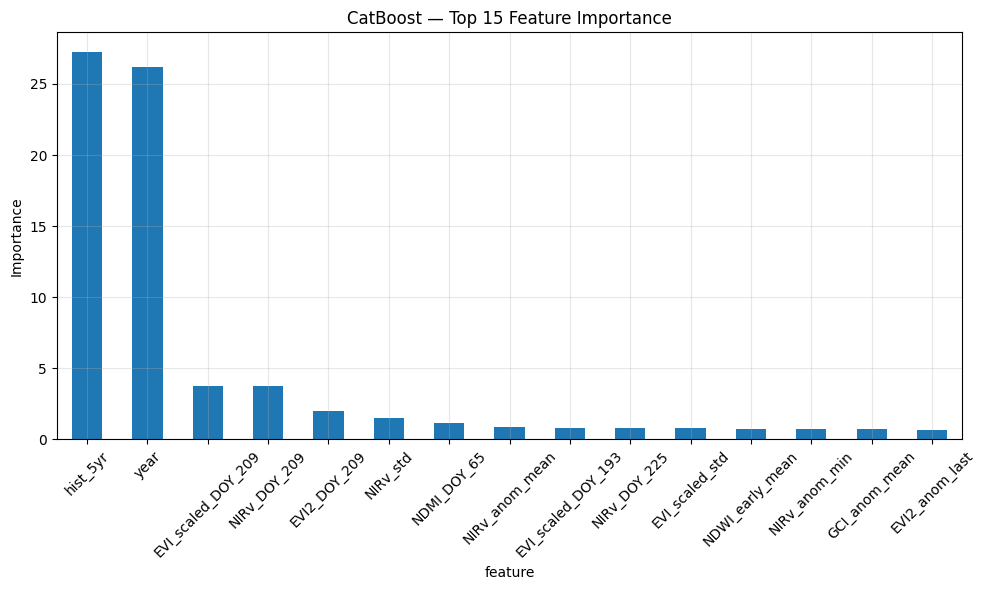

In [20]:
import matplotlib.pyplot as plt

# Get top 15 features overall
top15 = (
    feature_importance_direct_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
top15.plot(kind="bar")

plt.title("CatBoost — Top 15 Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

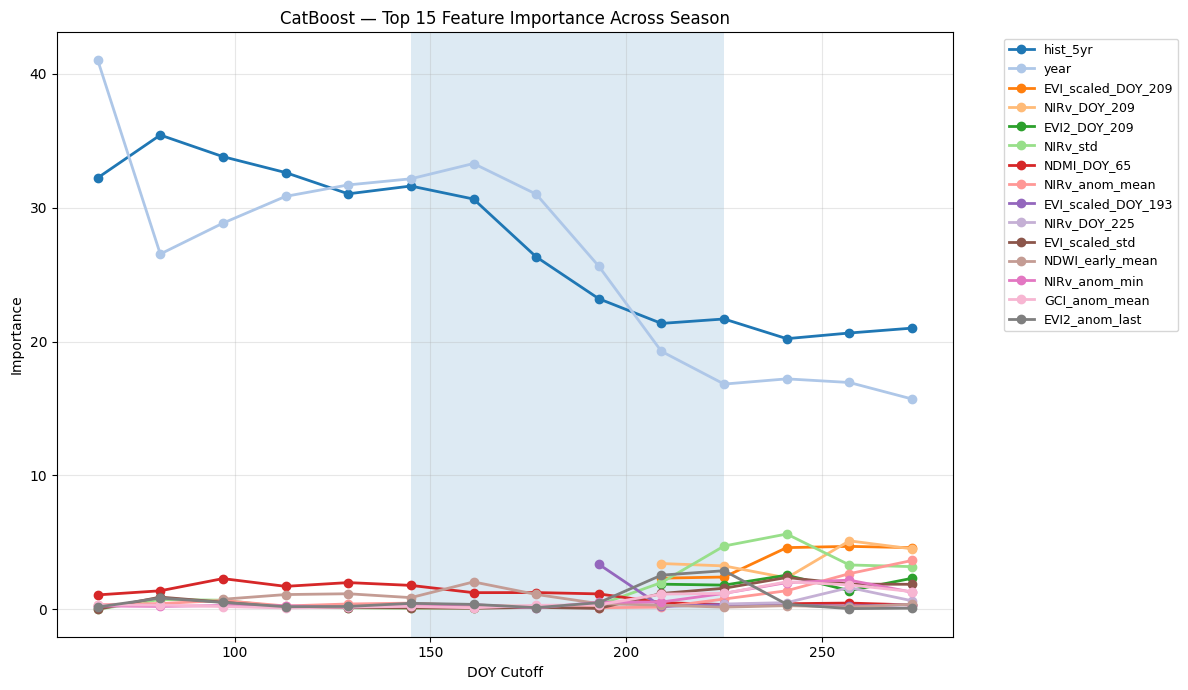

In [21]:
# Get top 15 feature names
top_features = top15.index

# Filter dataset
top_df = feature_importance_direct_df[
    feature_importance_direct_df["feature"].isin(top_features)
].copy()

# Aggregate across DOY
top_doy = (
    top_df
    .groupby(["DOY", "feature"])["importance"]
    .mean()
    .reset_index()
)

# Plot
colors = plt.cm.tab20.colors

plt.figure(figsize=(12,7))

for i, feat in enumerate(top_features):
    temp = top_doy[top_doy["feature"] == feat]
    plt.plot(
        temp["DOY"],
        temp["importance"],
        marker="o",
        linewidth=2,
        color=colors[i % len(colors)],
        label=feat
    )

plt.axvspan(145, 225, alpha=0.15)

plt.title("CatBoost — Top 15 Feature Importance Across Season")
plt.xlabel("DOY Cutoff")
plt.ylabel("Importance")
plt.grid(alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# DIRECT YIELD MODEL (NO ANOMALY) xgboost
# Train: df_prev_cdl
# Test:  df_prev_cdl
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

TEST_YEARS = list(range(2018, 2025))

results_direct = []
feature_importance_direct_rows = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # -----------------------------
        # TRAIN + TEST
        # -----------------------------
        train_df = df_prev_cdl[df_prev_cdl["year"] < yr].copy()
        test_df  = df_prev_cdl[df_prev_cdl["year"] == yr].copy()

        X_train = build_features(train_df, doy_cut)
        X_test  = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # -----------------------------
        # REMOVE LEAKAGE
        # -----------------------------
        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(columns=[c for c in leakage_cols if c in X_train.columns], errors="ignore")
        X_test  = X_test.drop(columns=[c for c in leakage_cols if c in X_test.columns], errors="ignore")

        # -----------------------------
        # ADD SAFE FEATURES (same as anomaly model)
        # -----------------------------
        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"]  = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"]  = test_df.loc[X_test.index, "year"]

        # -----------------------------
        # FILL NA
        # -----------------------------
        medians = X_train.median()
        X_train = X_train.fillna(medians)
        X_test  = X_test.fillna(medians)

        # -----------------------------
        # 🎯 DIRECT TARGET (KEY DIFFERENCE)
        # -----------------------------
        y_train = train_df.loc[X_train.index, "yield_filled"]
        y_test_actual = test_df.loc[X_test.index, "yield_bu_acre"].values

        # -----------------------------
        # MODEL
        # -----------------------------
        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, y_train)

        # -----------------------------
        # FEATURE IMPORTANCE
        # -----------------------------
        importance_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_,
            "year": yr,
            "DOY": doy_cut,
            "model": "direct"
        })

        feature_importance_direct_rows.append(importance_df)

        # -----------------------------
        # PREDICT DIRECTLY
        # -----------------------------
        pred_yield = model.predict(X_test)

        # -----------------------------
        # METRICS
        # -----------------------------
        r2 = r2_score(y_test_actual, pred_yield)
        rmse = np.sqrt(mean_squared_error(y_test_actual, pred_yield))

        results_direct.append({
            "year": yr,
            "DOY": doy_cut,
            "R2": r2,
            "RMSE": rmse
        })

        print(f"[DIRECT] Year {yr} | DOY {doy_cut} | R² = {r2:.3f}")

# ============================================================
# FINAL DATAFRAMES
# ============================================================

results_direct_df = pd.DataFrame(results_direct)

summary_direct = (
    results_direct_df
    .groupby("DOY")[["R2", "RMSE"]]
    .mean()
    .reset_index()
)

feature_importance_direct_df = pd.concat(feature_importance_direct_rows, ignore_index=True)

print("\n===== DIRECT MODEL SUMMARY =====")
display(summary_direct)


===== DOY 65 =====
[DIRECT] Year 2018 | DOY 65 | R² = 0.636
[DIRECT] Year 2019 | DOY 65 | R² = 0.540
[DIRECT] Year 2020 | DOY 65 | R² = 0.582
[DIRECT] Year 2021 | DOY 65 | R² = 0.622
[DIRECT] Year 2022 | DOY 65 | R² = 0.657
[DIRECT] Year 2023 | DOY 65 | R² = 0.709
[DIRECT] Year 2024 | DOY 65 | R² = 0.631

===== DOY 81 =====
[DIRECT] Year 2018 | DOY 81 | R² = 0.626
[DIRECT] Year 2019 | DOY 81 | R² = 0.515
[DIRECT] Year 2020 | DOY 81 | R² = 0.585
[DIRECT] Year 2021 | DOY 81 | R² = 0.614
[DIRECT] Year 2022 | DOY 81 | R² = 0.671
[DIRECT] Year 2023 | DOY 81 | R² = 0.704
[DIRECT] Year 2024 | DOY 81 | R² = 0.650

===== DOY 97 =====
[DIRECT] Year 2018 | DOY 97 | R² = 0.610
[DIRECT] Year 2019 | DOY 97 | R² = 0.547
[DIRECT] Year 2020 | DOY 97 | R² = 0.650
[DIRECT] Year 2021 | DOY 97 | R² = 0.624
[DIRECT] Year 2022 | DOY 97 | R² = 0.667
[DIRECT] Year 2023 | DOY 97 | R² = 0.702
[DIRECT] Year 2024 | DOY 97 | R² = 0.664

===== DOY 113 =====
[DIRECT] Year 2018 | DOY 113 | R² = 0.635
[DIRECT] Year 20

,DOY,R2,RMSE
0,65,0.625349,21.824537
1,81,0.623565,21.842532
2,97,0.637806,21.497872
3,113,0.648838,21.178722
4,129,0.645723,21.229970
5,145,0.656841,20.959548
6,161,0.675084,20.407019
7,177,0.693499,19.716485
8,193,0.705859,19.053682
9,209,0.746886,17.431133


Top 15 features:
EVI_scaled_DOY_209
hist_5yr
NIRv_DOY_209
EVI2_DOY_209
NIRv_std
EVI_scaled_max
EVI2_max
year
EVI_scaled_last
NIRv_DOY_193
EVI_scaled_DOY_193
NIRv_last
EVI2_DOY_193
NDVI_min
NIRv_slope


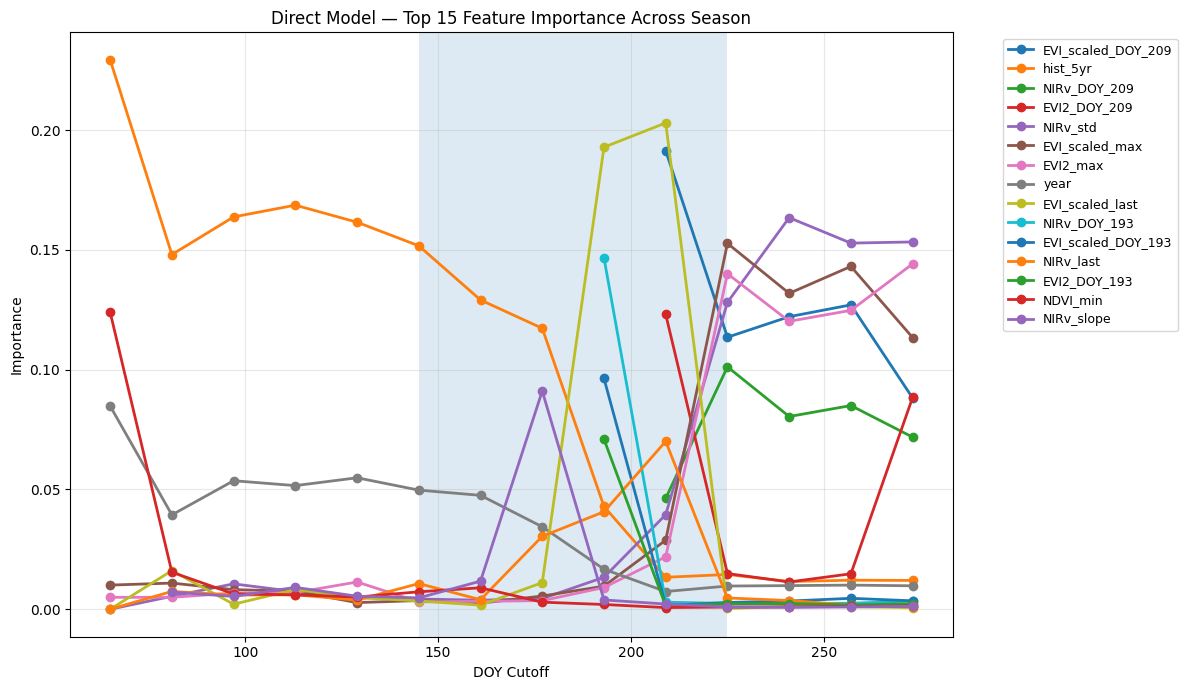

In [23]:
# ============================================================
# TOP 15 FEATURE IMPORTANCE ACROSS SEASON (DIRECT MODEL)
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# STEP 1 — GET TOP 15 FEATURES
# -----------------------------
top_features = (
    feature_importance_direct_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

print("Top 15 features:")
for f in top_features:
    print(f)

# -----------------------------
# STEP 2 — FILTER DATA
# -----------------------------
top_df = feature_importance_direct_df[
    feature_importance_direct_df["feature"].isin(top_features)
].copy()

# -----------------------------
# STEP 3 — AGGREGATE BY DOY
# -----------------------------
top_doy_importance = (
    top_df
    .groupby(["DOY", "feature"])["importance"]
    .mean()
    .reset_index()
)

# -----------------------------
# STEP 4 — PLOT
# -----------------------------
plt.figure(figsize=(12, 7))

for feat in top_features:
    temp = top_doy_importance[top_doy_importance["feature"] == feat]
    plt.plot(
        temp["DOY"],
        temp["importance"],
        marker="o",
        linewidth=2,
        label=feat
    )

# Peak growing season shading
plt.axvspan(145, 225, alpha=0.15)

plt.title("Direct Model — Top 15 Feature Importance Across Season")
plt.xlabel("DOY Cutoff")
plt.ylabel("Importance")
plt.grid(alpha=0.3)

# Clean legend (outside)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()

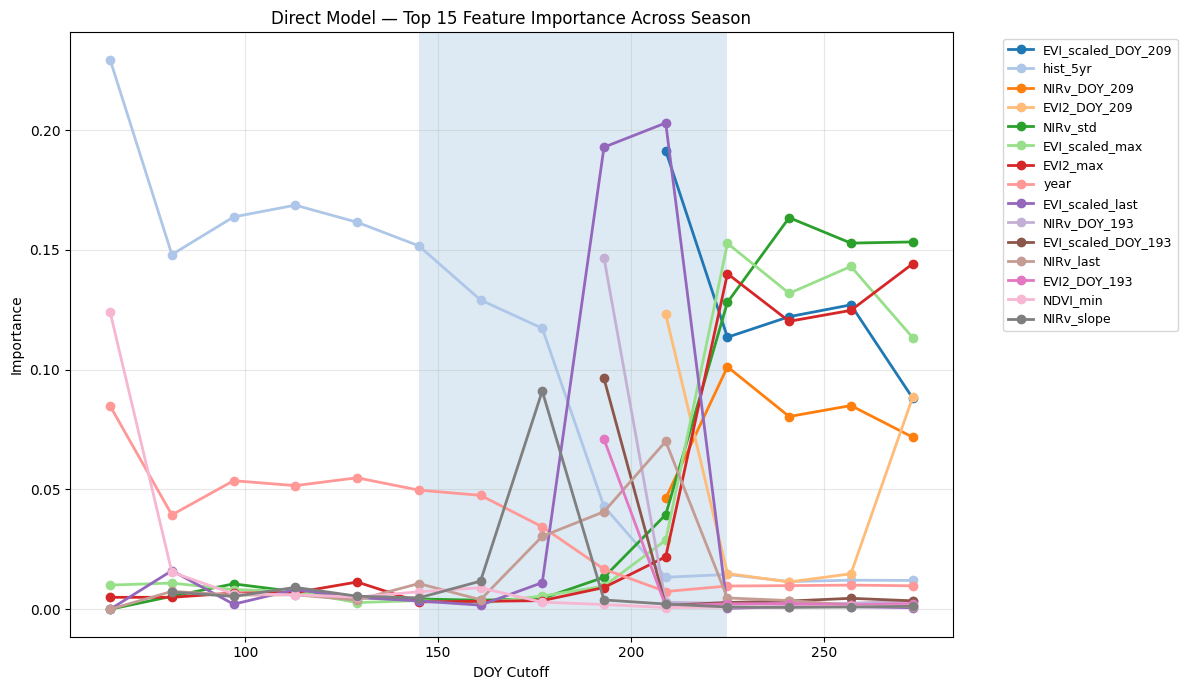

In [24]:
import matplotlib.pyplot as plt

colors = plt.cm.tab20.colors

plt.figure(figsize=(12, 7))

for i, feat in enumerate(top_features):
    temp = top_doy_importance[top_doy_importance["feature"] == feat]
    plt.plot(
        temp["DOY"],
        temp["importance"],
        marker="o",
        linewidth=2,
        color=colors[i % len(colors)],
        label=feat
    )

plt.axvspan(145, 225, alpha=0.15)

plt.title("Direct Model — Top 15 Feature Importance Across Season")
plt.xlabel("DOY Cutoff")
plt.ylabel("Importance")
plt.grid(alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# ANOMALY MODEL + FEATURE IMPORTANCE
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

TEST_YEARS = list(range(2018, 2025))

results_prev_anom = []
feature_importance_rows = []   # 🔥 NEW

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # -----------------------------
        # TRAIN + TEST
        # -----------------------------
        train_df = df_prev_cdl[df_prev_cdl["year"] < yr].copy()
        test_df  = df_prev_cdl[df_prev_cdl["year"] == yr].copy()

        X_train = build_features(train_df, doy_cut)
        X_test  = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # -----------------------------
        # REMOVE LEAKAGE
        # -----------------------------
        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(columns=[c for c in leakage_cols if c in X_train.columns], errors="ignore")
        X_test  = X_test.drop(columns=[c for c in leakage_cols if c in X_test.columns], errors="ignore")

        # -----------------------------
        # ADD SAFE FEATURES
        # -----------------------------
        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"]  = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"]  = test_df.loc[X_test.index, "year"]

        # -----------------------------
        # FILL NA
        # -----------------------------
        medians = X_train.median()
        X_train = X_train.fillna(medians)
        X_test  = X_test.fillna(medians)

        # -----------------------------
        # TARGET
        # -----------------------------
        y_train = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        y_test_actual = test_df.loc[X_test.index, "yield_bu_acre"].values

        # -----------------------------
        # MODEL
        # -----------------------------
        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, y_train)

        # =====================================================
        # 🔥 FEATURE IMPORTANCE (NEW)
        # =====================================================
        importance_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_,
            "year": yr,
            "DOY": doy_cut
        })

        feature_importance_rows.append(importance_df)

        # -----------------------------
        # PREDICTION
        # -----------------------------
        pred_anom = model.predict(X_test)

        pred_yield = (
            test_df.loc[X_test.index, "hist_5yr"].values +
            pred_anom
        )

        # -----------------------------
        # METRICS
        # -----------------------------
        r2 = r2_score(y_test_actual, pred_yield)
        rmse = np.sqrt(mean_squared_error(y_test_actual, pred_yield))

        results_prev_anom.append({
            "year": yr,
            "DOY": doy_cut,
            "R2": r2,
            "RMSE": rmse
        })

        print(f"Year {yr} | DOY {doy_cut} | R² = {r2:.3f}")

# ============================================================
# FINAL DATAFRAMES
# ============================================================

results_prev_anom_df = pd.DataFrame(results_prev_anom)

summary_prev_anom = (
    results_prev_anom_df
    .groupby("DOY")[["R2", "RMSE"]]
    .mean()
    .reset_index()
)

feature_importance_df = pd.concat(feature_importance_rows, ignore_index=True)

print("\n===== SUMMARY =====")
display(summary_prev_anom)

print("\n===== FEATURE IMPORTANCE SAMPLE =====")
display(feature_importance_df.head())


===== DOY 65 =====
Year 2018 | DOY 65 | R² = 0.667
Year 2019 | DOY 65 | R² = 0.512
Year 2020 | DOY 65 | R² = 0.526
Year 2021 | DOY 65 | R² = 0.645
Year 2022 | DOY 65 | R² = 0.673
Year 2023 | DOY 65 | R² = 0.726
Year 2024 | DOY 65 | R² = 0.645

===== DOY 81 =====
Year 2018 | DOY 81 | R² = 0.661
Year 2019 | DOY 81 | R² = 0.488
Year 2020 | DOY 81 | R² = 0.613
Year 2021 | DOY 81 | R² = 0.642
Year 2022 | DOY 81 | R² = 0.688
Year 2023 | DOY 81 | R² = 0.720
Year 2024 | DOY 81 | R² = 0.649

===== DOY 97 =====
Year 2018 | DOY 97 | R² = 0.657
Year 2019 | DOY 97 | R² = 0.554
Year 2020 | DOY 97 | R² = 0.609
Year 2021 | DOY 97 | R² = 0.622
Year 2022 | DOY 97 | R² = 0.681
Year 2023 | DOY 97 | R² = 0.709
Year 2024 | DOY 97 | R² = 0.660

===== DOY 113 =====
Year 2018 | DOY 113 | R² = 0.661
Year 2019 | DOY 113 | R² = 0.528
Year 2020 | DOY 113 | R² = 0.572
Year 2021 | DOY 113 | R² = 0.647
Year 2022 | DOY 113 | R² = 0.698
Year 2023 | DOY 113 | R² = 0.710
Year 2024 | DOY 113 | R² = 0.667

===== DOY 129 =

,DOY,R2,RMSE
0,65,0.627544,21.629886
1,81,0.637328,21.373173
2,97,0.641661,21.349750
3,113,0.640536,21.289966
4,129,0.643304,21.137234
5,145,0.657698,20.857212
6,161,0.679341,20.269024
7,177,0.699724,19.563098
8,193,0.718053,18.874777
9,209,0.753619,17.400922



===== FEATURE IMPORTANCE SAMPLE =====


,feature,importance,year,DOY
0,NDVI_DOY_65,0.017353,2018,65
1,NDVI_mean,0.018944,2018,65
2,NDVI_max,0.010973,2018,65
3,NDVI_min,0.067998,2018,65
4,NDVI_std,0.000000,2018,65


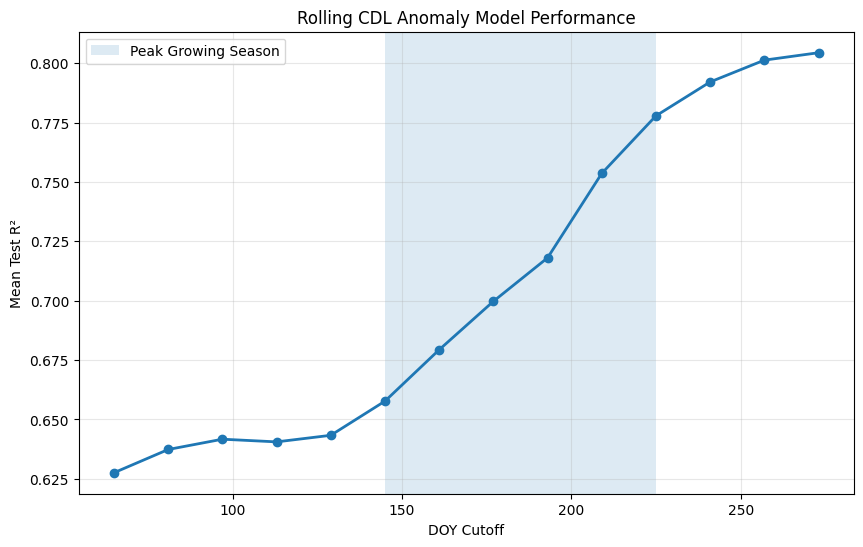

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    summary_prev_anom["DOY"],
    summary_prev_anom["R2"],
    marker="o",
    linewidth=2
)

plt.axvspan(145, 225, alpha=0.15, label="Peak Growing Season")

plt.xlabel("DOY Cutoff")
plt.ylabel("Mean Test R²")
plt.title("Rolling CDL Anomaly Model Performance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

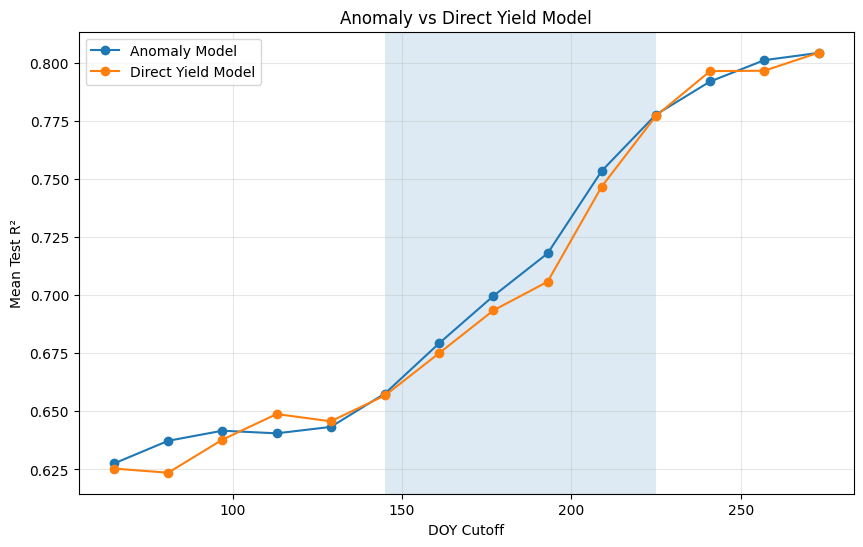

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(summary_prev_anom["DOY"], summary_prev_anom["R2"],
         marker="o", label="Anomaly Model")

plt.plot(summary_direct["DOY"], summary_direct["R2"],
         marker="o", label="Direct Yield Model")

plt.axvspan(145, 225, alpha=0.15)

plt.xlabel("DOY Cutoff")
plt.ylabel("Mean Test R²")
plt.title("Anomaly vs Direct Yield Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# MULTI-MODEL COMPARISON (UPDATED PIPELINE)
# Rolling CDL + Anomaly Target
# ============================================================

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import pandas as pd
import numpy as np

TEST_YEARS = list(range(2020, 2025))

results = []
feature_importance_rows = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # ====================================================
        # TRAIN: previous-YEAR CDL
        # TEST:  PREVIOUS-YEAR CDL
        # ====================================================
        train_df = df_prev_cdl[df_prev_cdl["year"] < yr].copy()
        test_df  = df_prev_cdl[df_prev_cdl["year"] == yr].copy()

        X_train = build_features(train_df, doy_cut)
        X_test  = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # ====================================================
        # REMOVE LEAKAGE
        # ====================================================
        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(columns=[c for c in leakage_cols if c in X_train.columns], errors="ignore")
        X_test  = X_test.drop(columns=[c for c in leakage_cols if c in X_test.columns], errors="ignore")

        # ====================================================
        # ADD SAFE FEATURES
        # ====================================================
        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"]  = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"]  = test_df.loc[X_test.index, "year"]

        # ====================================================
        # FILL NA (TRAIN MEDIANS)
        # ====================================================
        medians = X_train.median()
        X_train = X_train.fillna(medians)
        X_test  = X_test.fillna(medians)

        # ====================================================
        # ANOMALY TARGET
        # ====================================================
        y_train = (
            train_df.loc[X_train.index, "yield_filled"]
            - train_df.loc[X_train.index, "hist_5yr"]
        )

        y_test_actual = test_df.loc[X_test.index, "yield_bu_acre"].values

        # ====================================================
        # MODELS
        # ====================================================
        models = {
            "XGBoost": XGBRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            ),

            "RandomForest": RandomForestRegressor(
                n_estimators=400,
                max_depth=12,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            ),

            "CatBoost": CatBoostRegressor(
                iterations=400,
                depth=6,
                learning_rate=0.05,
                loss_function="RMSE",
                verbose=0,
                random_seed=42
            ),

            "SVR": Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(
                    kernel="rbf",
                    C=15,
                    epsilon=0.05,
                    gamma="scale"
                ))
            ])
        }

        # ====================================================
        # TRAIN + EVALUATE
        # ====================================================
        for model_name, model in models.items():

            model.fit(X_train, y_train)

            pred_anom = model.predict(X_test)

            pred_yield = (
                test_df.loc[X_test.index, "hist_5yr"].values
                + pred_anom
            )

            r2 = r2_score(y_test_actual, pred_yield)
            rmse = np.sqrt(mean_squared_error(y_test_actual, pred_yield))

            results.append({
                "year": yr,
                "DOY": doy_cut,
                "model": model_name,
                "R2": r2,
                "RMSE": rmse
            })

            print(f"{model_name} | Year {yr} | DOY {doy_cut} | R² = {r2:.3f}")

            # ====================================================
            # FEATURE IMPORTANCE (TREE MODELS ONLY)
            # ====================================================
            if model_name in ["XGBoost", "RandomForest", "CatBoost"]:

                if model_name == "CatBoost":
                    importance = model.get_feature_importance()
                else:
                    importance = model.feature_importances_

                fi_df = pd.DataFrame({
                    "feature": X_train.columns,
                    "importance": importance,
                    "year": yr,
                    "DOY": doy_cut,
                    "model": model_name
                })

                feature_importance_rows.append(fi_df)

# ============================================================
# FINAL DATAFRAMES
# ============================================================

results_df = pd.DataFrame(results)

summary_df = (
    results_df
    .groupby(["DOY", "model"])[["R2", "RMSE"]]
    .mean()
    .reset_index()
)

feature_importance_df = pd.concat(feature_importance_rows, ignore_index=True)

print("\n===== FINAL SUMMARY =====")
display(summary_df)

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for model in summary_df["model"].unique():
    temp = summary_df[summary_df["model"] == model]
    plt.plot(temp["DOY"], temp["R2"], marker="o", label=model)

plt.axvspan(145, 225, alpha=0.15)

plt.title("Multi-Model Comparison (Anomaly Target)")
plt.xlabel("DOY Cutoff")
plt.ylabel("Mean R²")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

NameError: name 'summary_df' is not defined

<Figure size 1000x600 with 0 Axes>

In [32]:
# ============================================================
# CELL 1: DOWNLOAD TIGER COUNTY SHAPEFILE
# ============================================================

import geopandas as gpd

tiger_url = "https://www2.census.gov/geo/tiger/TIGER2018/COUNTY/tl_2018_us_county.zip"

county_shapes = gpd.read_file(tiger_url)

print("County rows:", len(county_shapes))
print(county_shapes.columns.tolist())

County rows: 3233
['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


In [33]:
# ============================================================
# CELL 2: BUILD FIPS COLUMN
# ============================================================

county_shapes["FIPS"] = (
    county_shapes["STATEFP"].astype(str) +
    county_shapes["COUNTYFP"].astype(str)
)

county_shapes["FIPS"] = county_shapes["FIPS"].str.zfill(5)

print(county_shapes[["STATEFP", "COUNTYFP", "FIPS", "NAME"]].head())

  STATEFP COUNTYFP   FIPS       NAME
0      31      039  31039     Cuming
1      53      069  53069  Wahkiakum
2      35      011  35011    De Baca
3      31      109  31109  Lancaster
4      31      129  31129   Nuckolls


In [34]:
# ============================================================
# CELL 3: KEEP ONLY CORN BELT STATES
# ============================================================

corn_belt_states = [
    "19",  # Iowa
    "17",  # Illinois
    "18",  # Indiana
    "31",  # Nebraska
    "27",  # Minnesota
    "29",  # Missouri
    "20",  # Kansas
    "46",  # South Dakota
    "38",  # North Dakota
    "39",  # Ohio
    "55",  # Wisconsin
    "26"   # Michigan
]

county_shapes = county_shapes[
    county_shapes["STATEFP"].isin(corn_belt_states)
].copy()

print("Filtered county rows:", len(county_shapes))
print(county_shapes["STATEFP"].value_counts().sort_index())

Filtered county rows: 1055
STATEFP
17    102
18     92
19     99
20    105
26     83
27     87
29    115
31     93
38     53
39     88
46     66
55     72
Name: count, dtype: int64


Using county ID column: GEOID
Running DOY 65
Running DOY 81
Running DOY 97
Running DOY 113
Running DOY 129
Running DOY 145
Running DOY 161
Running DOY 177
Running DOY 193
Running DOY 209
Running DOY 225
Running DOY 241
Running DOY 257
Running DOY 273


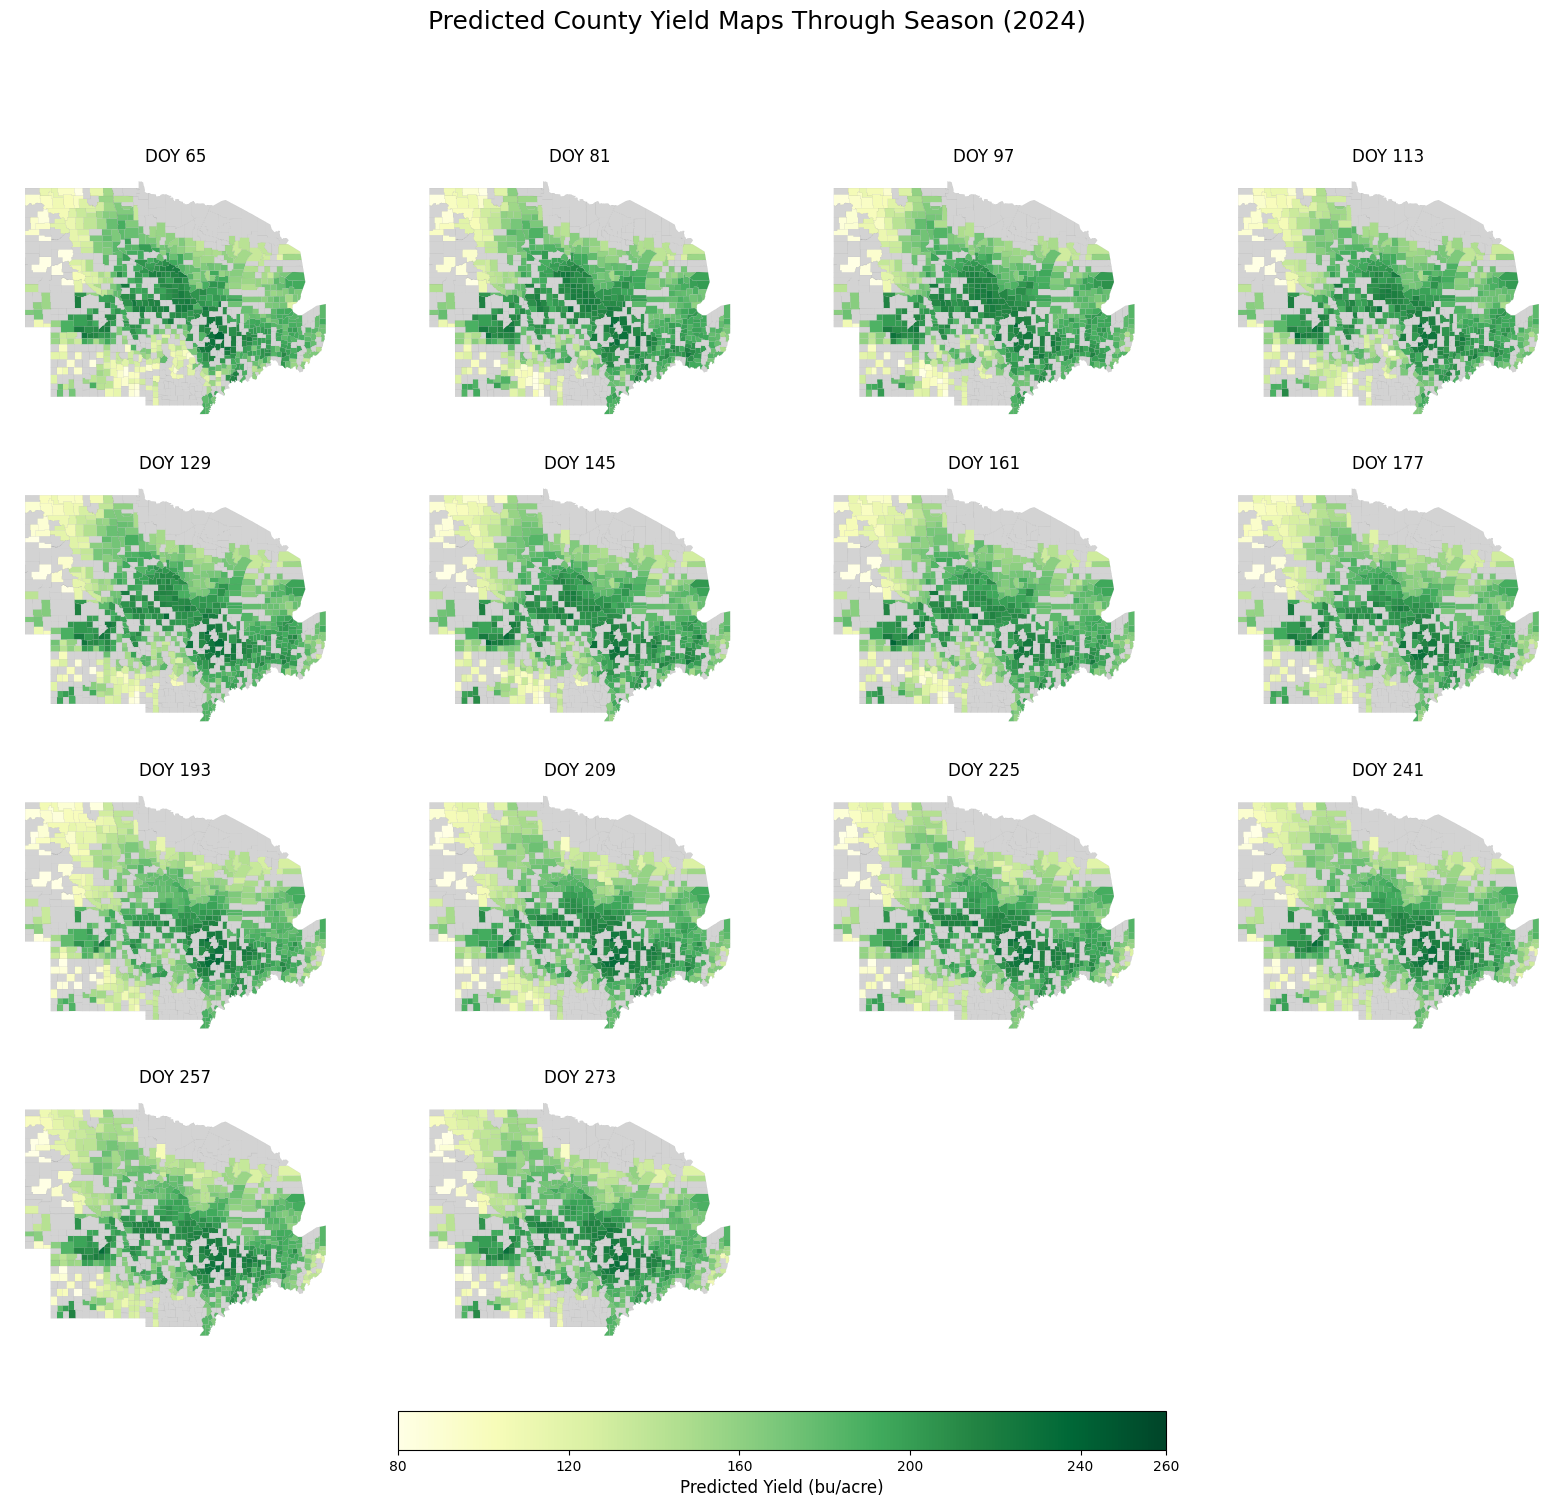

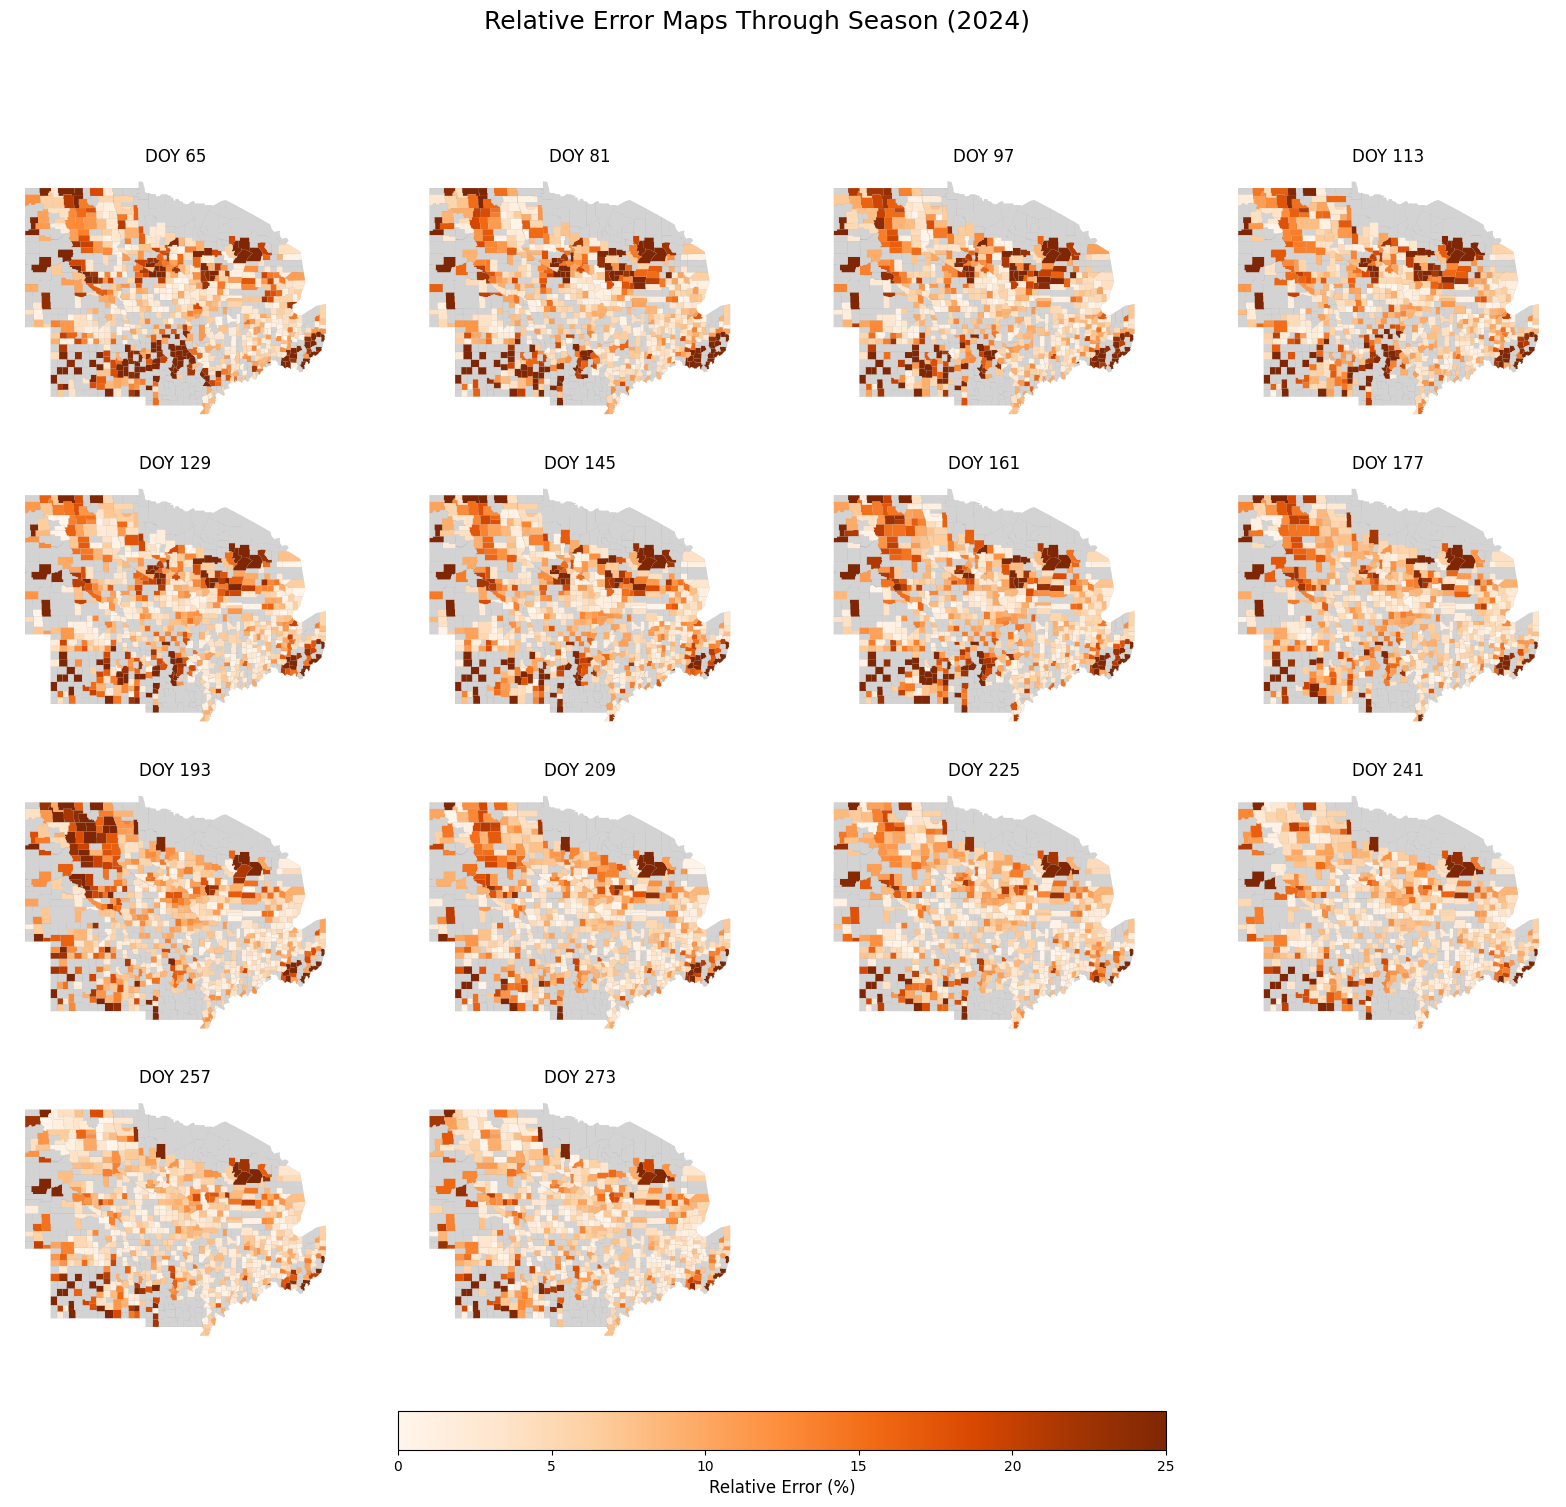

In [35]:

# ============================================================
# SEASONAL YIELD + ERROR MAPS THROUGH THE YEAR
# Includes shared colorbars and fixed scales
# One panel per 16-day DOY cutoff
# ============================================================



# ============================================================
# SETTINGS
# ============================================================

TEST_YEAR = 2024
DOY_LIST = list(range(65, 275, 16))

# ============================================================
# LEAKAGE COLUMNS
# ============================================================

leakage_cols = [
    "yield_bu_acre",
    "yield_filled",
    "yield_anomaly",
    "target",
    "yield"
]

# ============================================================
# FIND COUNTY ID COLUMN
# ============================================================

possible_fips_cols = [
    "FIPS",
    "fips",
    "GEOID",
    "geoid",
    "county_fips",
    "CountyFIPS"
]

fips_col = None
for col in possible_fips_cols:
    if col in df_prev_cdl.columns:
        fips_col = col
        break

print("Using county ID column:", fips_col)

# ============================================================
# CREATE PANEL FIGURES
# ============================================================

ncols = 4
nrows = int(np.ceil(len(DOY_LIST) / ncols))

fig_yield, axes_yield = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 4 * nrows)
)

fig_error, axes_error = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 4 * nrows)
)

axes_yield = axes_yield.flatten()
axes_error = axes_error.flatten()

# ============================================================
# LOOP THROUGH DOYS
# ============================================================

for i, doy_cut in enumerate(DOY_LIST):

    print(f"Running DOY {doy_cut}")

    # ------------------------------------------------
    # TRAIN / TEST SPLIT
    # ------------------------------------------------

    train_df = df_prev_cdl[
        df_prev_cdl["year"] < TEST_YEAR
    ].copy()

    test_df = df_prev_cdl[
        df_prev_cdl["year"] == TEST_YEAR
    ].copy()

    X_train = build_features(train_df, doy_cut)
    X_test = build_features(test_df, doy_cut)

    if X_train.empty or X_test.empty:
        print(f"Skipping DOY {doy_cut} because features are empty")
        continue

    # ------------------------------------------------
    # REMOVE LEAKAGE COLUMNS
    # ------------------------------------------------

    X_train = X_train.drop(
        columns=[c for c in leakage_cols if c in X_train.columns],
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=[c for c in leakage_cols if c in X_test.columns],
        errors="ignore"
    )

    # ------------------------------------------------
    # ADD SAFE FEATURES
    # ------------------------------------------------

    X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
    X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

    # Uncomment if you want to include year as a feature
    # X_train["year"] = train_df.loc[X_train.index, "year"]
    # X_test["year"] = test_df.loc[X_test.index, "year"]

    # ------------------------------------------------
    # FILL MISSING VALUES
    # ------------------------------------------------

    medians = X_train.median()

    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)

    # ------------------------------------------------
    # TARGET = YIELD ANOMALY
    # ------------------------------------------------

    y_train = (
        train_df.loc[X_train.index, "yield_filled"] -
        train_df.loc[X_train.index, "hist_5yr"]
    )

    # ------------------------------------------------
    # MODEL
    # ------------------------------------------------

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_anomaly = model.predict(X_test)

    pred_yield = (
        test_df.loc[X_test.index, "hist_5yr"].values +
        pred_anomaly
    )

    # ------------------------------------------------
    # BUILD COUNTY RESULTS
    # ------------------------------------------------

    temp_results = test_df.loc[
        X_test.index,
        [fips_col, "yield_bu_acre"]
    ].copy()

    temp_results = temp_results.rename(
        columns={fips_col: "FIPS"}
    )

    temp_results["FIPS"] = (
        temp_results["FIPS"]
        .astype(str)
        .str.zfill(5)
    )

    temp_results["predicted_bu_acre"] = pred_yield

    temp_results["abs_error_bu_acre"] = np.abs(
        temp_results["predicted_bu_acre"] -
        temp_results["yield_bu_acre"]
    )

    temp_results["relative_error_pct"] = (
        temp_results["abs_error_bu_acre"] /
        temp_results["yield_bu_acre"]
    ) * 100

    # ------------------------------------------------
    # MERGE WITH COUNTY SHAPES
    # ------------------------------------------------

    temp_map = county_shapes.merge(
        temp_results,
        on="FIPS",
        how="left"
    )

    # ------------------------------------------------
    # PLOT YIELD MAP
    # ------------------------------------------------

    temp_map.plot(
        column="predicted_bu_acre",
        cmap="YlGn",
        linewidth=0.05,
        edgecolor="gray",
        ax=axes_yield[i],
        legend=False,
        vmin=80,
        vmax=260,
        missing_kwds={"color": "lightgray"}
    )

    axes_yield[i].set_title(f"DOY {doy_cut}")
    axes_yield[i].axis("off")

    # ------------------------------------------------
    # PLOT ERROR MAP
    # ------------------------------------------------

    temp_map.plot(
        column="relative_error_pct",
        cmap="Oranges",
        linewidth=0.05,
        edgecolor="gray",
        ax=axes_error[i],
        legend=False,
        vmin=0,
        vmax=25,
        missing_kwds={"color": "lightgray"}
    )

    axes_error[i].set_title(f"DOY {doy_cut}")
    axes_error[i].axis("off")

# ============================================================
# TURN OFF EXTRA EMPTY PANELS
# ============================================================

for j in range(len(DOY_LIST), len(axes_yield)):
    axes_yield[j].axis("off")
    axes_error[j].axis("off")

# ============================================================
# FINAL FORMATTING
# ============================================================

fig_yield.suptitle(
    f"Predicted County Yield Maps Through Season ({TEST_YEAR})",
    fontsize=18,
    y=0.98
)

fig_error.suptitle(
    f"Relative Error Maps Through Season ({TEST_YEAR})",
    fontsize=18,
    y=0.98
)

# Leave room at bottom for colorbars
fig_yield.subplots_adjust(bottom=0.08)
fig_error.subplots_adjust(bottom=0.08)

# ============================================================
# CREATE COLOR SC
# ============================================================
# CREATE SHARED COLORBARS (WITH TICKS)
# ============================================================

import matplotlib as mpl

# ------------------------------------------------------------
# YIELD COLORBAR
# ------------------------------------------------------------
sm_yield = mpl.cm.ScalarMappable(
    cmap="YlGn",
    norm=mpl.colors.Normalize(vmin=80, vmax=260)
)
sm_yield.set_array([])

cbar_yield = fig_yield.colorbar(
    sm_yield,
    ax=axes_yield,
    orientation="horizontal",
    fraction=0.03,
    pad=0.05
)

cbar_yield.set_label("Predicted Yield (bu/acre)", fontsize=12)

# ✅ TICKS
cbar_yield.set_ticks([80, 120, 160, 200, 240, 260])


# ------------------------------------------------------------
# ERROR COLORBAR
# ------------------------------------------------------------
sm_error = mpl.cm.ScalarMappable(
    cmap="Oranges",
    norm=mpl.colors.Normalize(vmin=0, vmax=25)
)
sm_error.set_array([])

cbar_error = fig_error.colorbar(
    sm_error,
    ax=axes_error,
    orientation="horizontal",
    fraction=0.03,
    pad=0.05
)

cbar_error.set_label("Relative Error (%)", fontsize=12)

# ✅ TICKS
cbar_error.set_ticks([0, 5, 10, 15, 20, 25])


# ------------------------------------------------------------
# SHOW FIGURES
# ------------------------------------------------------------
plt.show()

Using county ID column: GEOID
Running DOY 65
Running DOY 81
Running DOY 97
Running DOY 113
Running DOY 129
Running DOY 145
Running DOY 161
Running DOY 177
Running DOY 193
Running DOY 209
Running DOY 225
Running DOY 241
Running DOY 257
Running DOY 273


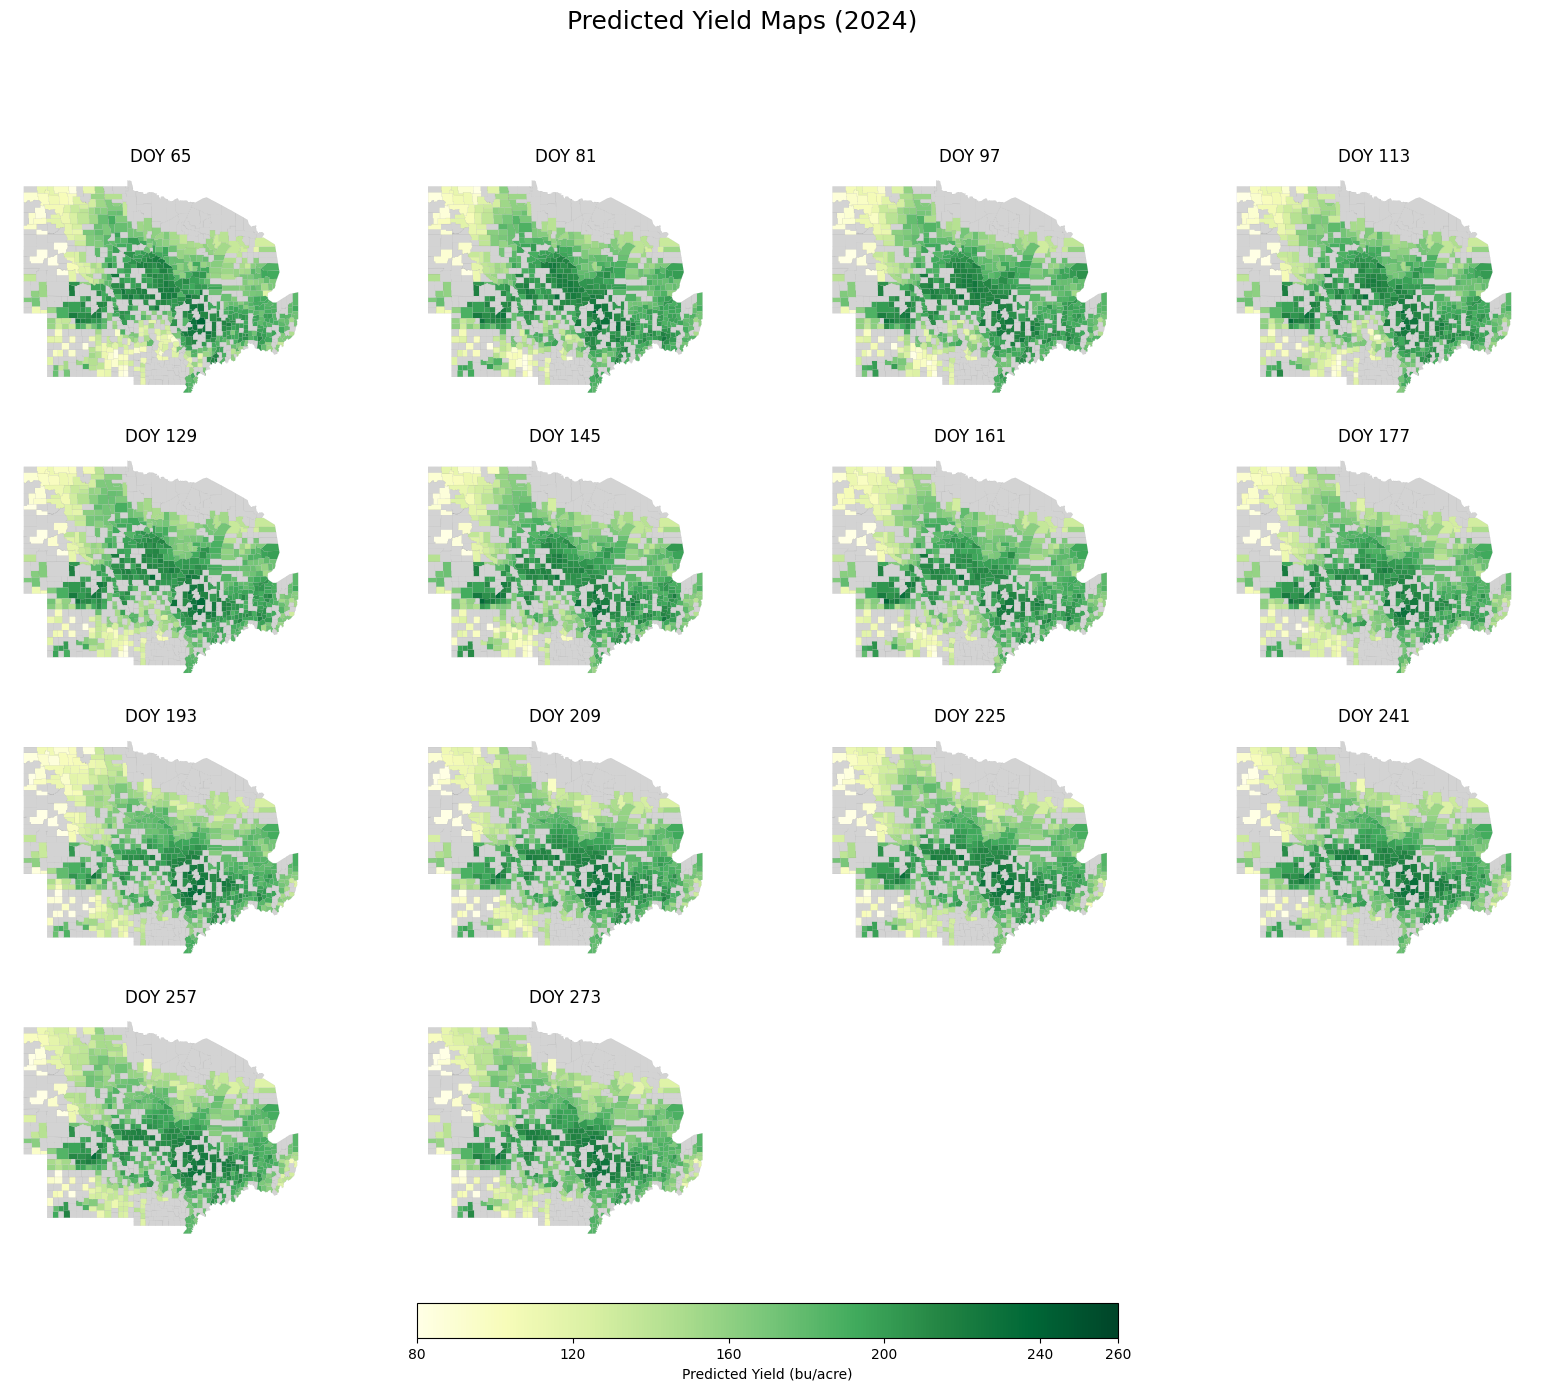

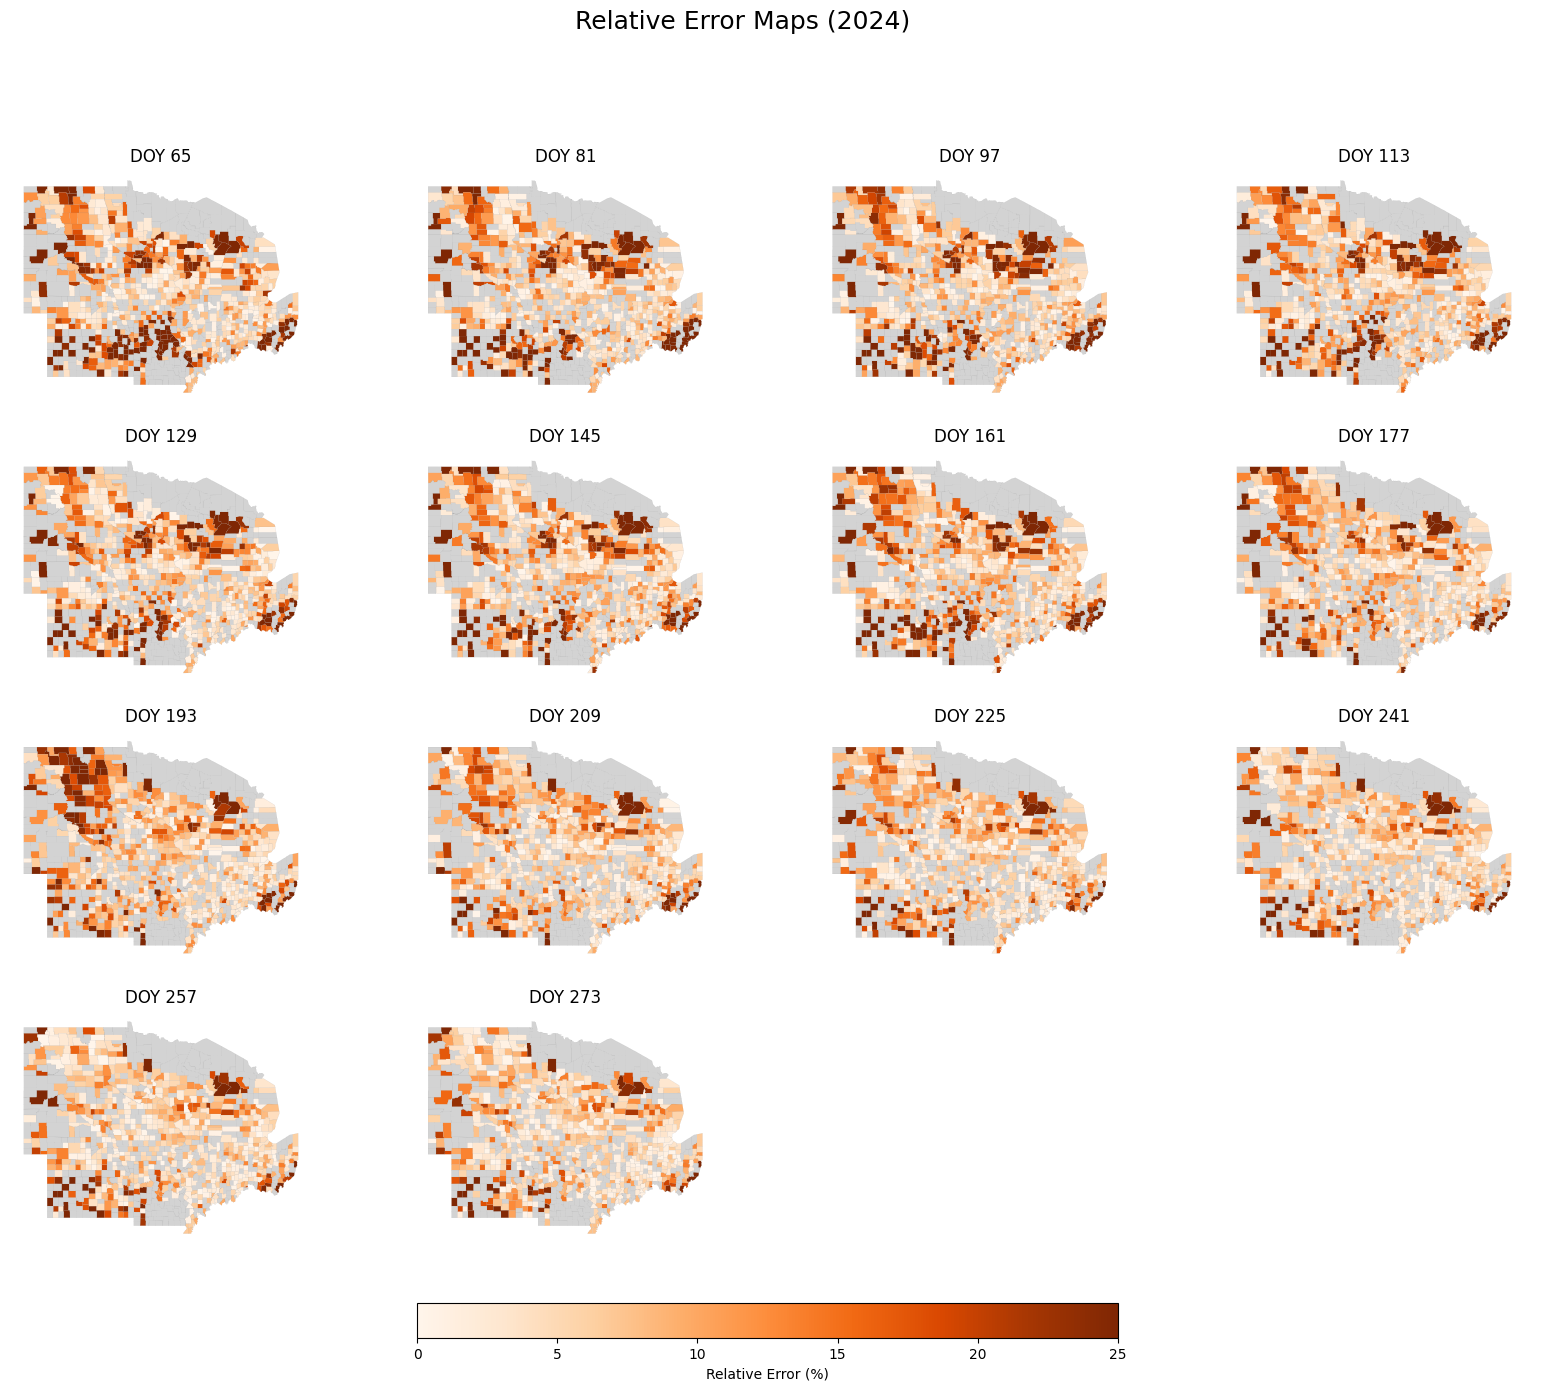

In [44]:
# ============================================================
# SEASONAL YIELD + ERROR MAPS THROUGH THE YEAR (FINAL CLEAN)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from xgboost import XGBRegressor

# ============================================================
# SETTINGS
# ============================================================

TEST_YEAR = 2024
DOY_LIST = list(range(65, 275, 16))

leakage_cols = [
    "yield_bu_acre",
    "yield_filled",
    "yield_anomaly",
    "target",
    "yield"
]

# ============================================================
# FIND COUNTY ID COLUMN
# ============================================================

possible_fips_cols = ["FIPS","fips","GEOID","geoid","county_fips","CountyFIPS"]

fips_col = next((c for c in possible_fips_cols if c in df_prev_cdl.columns), None)
print("Using county ID column:", fips_col)

# ============================================================
# CREATE FIGURES
# ============================================================

ncols = 4
nrows = int(np.ceil(len(DOY_LIST) / ncols))

fig_yield, axes_yield = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))
fig_error, axes_error = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))

axes_yield = axes_yield.flatten()
axes_error = axes_error.flatten()

# ============================================================
# LOOP THROUGH DOYs
# ============================================================

for i, doy_cut in enumerate(DOY_LIST):

    print(f"Running DOY {doy_cut}")

    train_df = df_prev_cdl[df_prev_cdl["year"] < TEST_YEAR].copy()
    test_df  = df_prev_cdl[df_prev_cdl["year"] == TEST_YEAR].copy()

    X_train = build_features(train_df, doy_cut)
    X_test  = build_features(test_df, doy_cut)

    if X_train.empty or X_test.empty:
        axes_yield[i].axis("off")
        axes_error[i].axis("off")
        continue

    # Remove leakage
    X_train = X_train.drop(columns=[c for c in leakage_cols if c in X_train.columns], errors="ignore")
    X_test  = X_test.drop(columns=[c for c in leakage_cols if c in X_test.columns], errors="ignore")

    # Add features
    X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
    X_test["hist_5yr"]  = test_df.loc[X_test.index, "hist_5yr"]

    # Fill NA
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)

    # Target
    y_train = (
        train_df.loc[X_train.index, "yield_filled"] -
        train_df.loc[X_train.index, "hist_5yr"]
    )

    # Model
    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_anom = model.predict(X_test)

    pred_yield = (
        test_df.loc[X_test.index, "hist_5yr"].values +
        pred_anom
    )

    # Build results
    temp = test_df.loc[X_test.index, [fips_col, "yield_bu_acre"]].copy()
    temp = temp.rename(columns={fips_col: "FIPS"})
    temp["FIPS"] = temp["FIPS"].astype(str).str.zfill(5)

    temp["predicted_bu_acre"] = pred_yield
    temp["relative_error_pct"] = (
        np.abs(temp["predicted_bu_acre"] - temp["yield_bu_acre"]) /
        temp["yield_bu_acre"]
    ) * 100

    temp_map = county_shapes.merge(temp, on="FIPS", how="left")

    # Yield map
    temp_map.plot(
        column="predicted_bu_acre",
        cmap="YlGn",
        linewidth=0.05,
        edgecolor="gray",
        ax=axes_yield[i],
        vmin=80,
        vmax=260,
        legend=False,
        missing_kwds={"color": "lightgray"}
    )

    axes_yield[i].set_title(f"DOY {doy_cut}")
    axes_yield[i].axis("off")

    # Error map
    temp_map.plot(
        column="relative_error_pct",
        cmap="Oranges",
        linewidth=0.05,
        edgecolor="gray",
        ax=axes_error[i],
        vmin=0,
        vmax=25,
        legend=False,
        missing_kwds={"color": "lightgray"}
    )

    axes_error[i].set_title(f"DOY {doy_cut}")
    axes_error[i].axis("off")

# Turn off extra axes
for j in range(len(DOY_LIST), len(axes_yield)):
    axes_yield[j].axis("off")
    axes_error[j].axis("off")

# ============================================================
# TITLES + SPACING
# ============================================================

fig_yield.suptitle(f"Predicted Yield Maps ({TEST_YEAR})", fontsize=18)
fig_error.suptitle(f"Relative Error Maps ({TEST_YEAR})", fontsize=18)

fig_yield.subplots_adjust(bottom=0.15)
fig_error.subplots_adjust(bottom=0.15)

# ============================================================
# COLORBARS (WORKING VERSION)
# ============================================================

# Yield colorbar
sm_yield = mpl.cm.ScalarMappable(
    cmap="YlGn",
    norm=mpl.colors.Normalize(vmin=80, vmax=260)
)
sm_yield.set_array([])

cbar_yield = fig_yield.colorbar(
    sm_yield,
    ax=axes_yield.tolist(),
    orientation="horizontal",
    fraction=0.03,
    pad=0.05
)
cbar_yield.set_label("Predicted Yield (bu/acre)")
cbar_yield.set_ticks([80, 120, 160, 200, 240, 260])

# Error colorbar
sm_error = mpl.cm.ScalarMappable(
    cmap="Oranges",
    norm=mpl.colors.Normalize(vmin=0, vmax=25)
)
sm_error.set_array([])

cbar_error = fig_error.colorbar(
    sm_error,
    ax=axes_error.tolist(),
    orientation="horizontal",
    fraction=0.03,
    pad=0.05
)
cbar_error.set_label("Relative Error (%)")
cbar_error.set_ticks([0, 5, 10, 15, 20, 25])

plt.show()

In [46]:
# ============================================================
# R2 / RMSE THROUGH THE SEASON (CLEAN + FIXED)
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

performance_results = []

DOY_LIST = list(range(65, 275, 16))

for doy_cut in DOY_LIST:

    print(f"Running DOY {doy_cut}")

    # ------------------------------------------------
    # TRAIN / TEST SPLIT (CORRECT SETUP)
    # ------------------------------------------------
    train_df = df_prev_cdl[df_prev_cdl["year"] < TEST_YEAR].copy()
    test_df  = df_prev_cdl[df_prev_cdl["year"] == TEST_YEAR].copy()

    X_train = build_features(train_df, doy_cut)
    X_test  = build_features(test_df, doy_cut)

    if X_train.empty or X_test.empty:
        continue

    # ------------------------------------------------
    # REMOVE LEAKAGE
    # ------------------------------------------------
    X_train = X_train.drop(
        columns=[c for c in leakage_cols if c in X_train.columns],
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=[c for c in leakage_cols if c in X_test.columns],
        errors="ignore"
    )

    # ------------------------------------------------
    # ADD SAFE FEATURES
    # ------------------------------------------------
    X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
    X_test["hist_5yr"]  = test_df.loc[X_test.index, "hist_5yr"]

    # 👉 Optional (keep consistent with maps)
    # X_train["year"] = train_df.loc[X_train.index, "year"]
    # X_test["year"]  = test_df.loc[X_test.index, "year"]

    # ------------------------------------------------
    # FILL NA (TRAIN MEDIANS ONLY)
    # ------------------------------------------------
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)

    # ------------------------------------------------
    # TARGET (ANOMALY)
    # ------------------------------------------------
    y_train = (
        train_df.loc[X_train.index, "yield_filled"]
        - train_df.loc[X_train.index, "hist_5yr"]
    )

    y_test_actual = test_df.loc[X_test.index, "yield_bu_acre"].values

    # ------------------------------------------------
    # MODEL
    # ------------------------------------------------
    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_anomaly = model.predict(X_test)

    # ------------------------------------------------
    # CONVERT BACK TO YIELD
    # ------------------------------------------------
    pred_yield = (
        test_df.loc[X_test.index, "hist_5yr"].values
        + pred_anomaly
    )

    # ------------------------------------------------
    # METRICS
    # ------------------------------------------------
    r2 = r2_score(y_test_actual, pred_yield)
    rmse = np.sqrt(mean_squared_error(y_test_actual, pred_yield))

    performance_results.append({
        "DOY": doy_cut,
        "R2": r2,
        "RMSE": rmse
    })

# ------------------------------------------------------------
# FINAL DF
# ------------------------------------------------------------
performance_df = pd.DataFrame(performance_results)

print("\n===== PERFORMANCE =====")
display(performance_df)

Running DOY 65
Running DOY 81
Running DOY 97
Running DOY 113
Running DOY 129
Running DOY 145
Running DOY 161
Running DOY 177
Running DOY 193
Running DOY 209
Running DOY 225
Running DOY 241
Running DOY 257
Running DOY 273

===== PERFORMANCE =====


,DOY,R2,RMSE
0,65,0.485509,25.488632
1,81,0.594407,22.630932
2,97,0.595288,22.606365
3,113,0.587406,22.825437
4,129,0.638850,21.355078
5,145,0.636639,21.420344
6,161,0.613238,22.099331
7,177,0.718192,18.864024
8,193,0.693440,19.675026
9,209,0.779761,16.676484


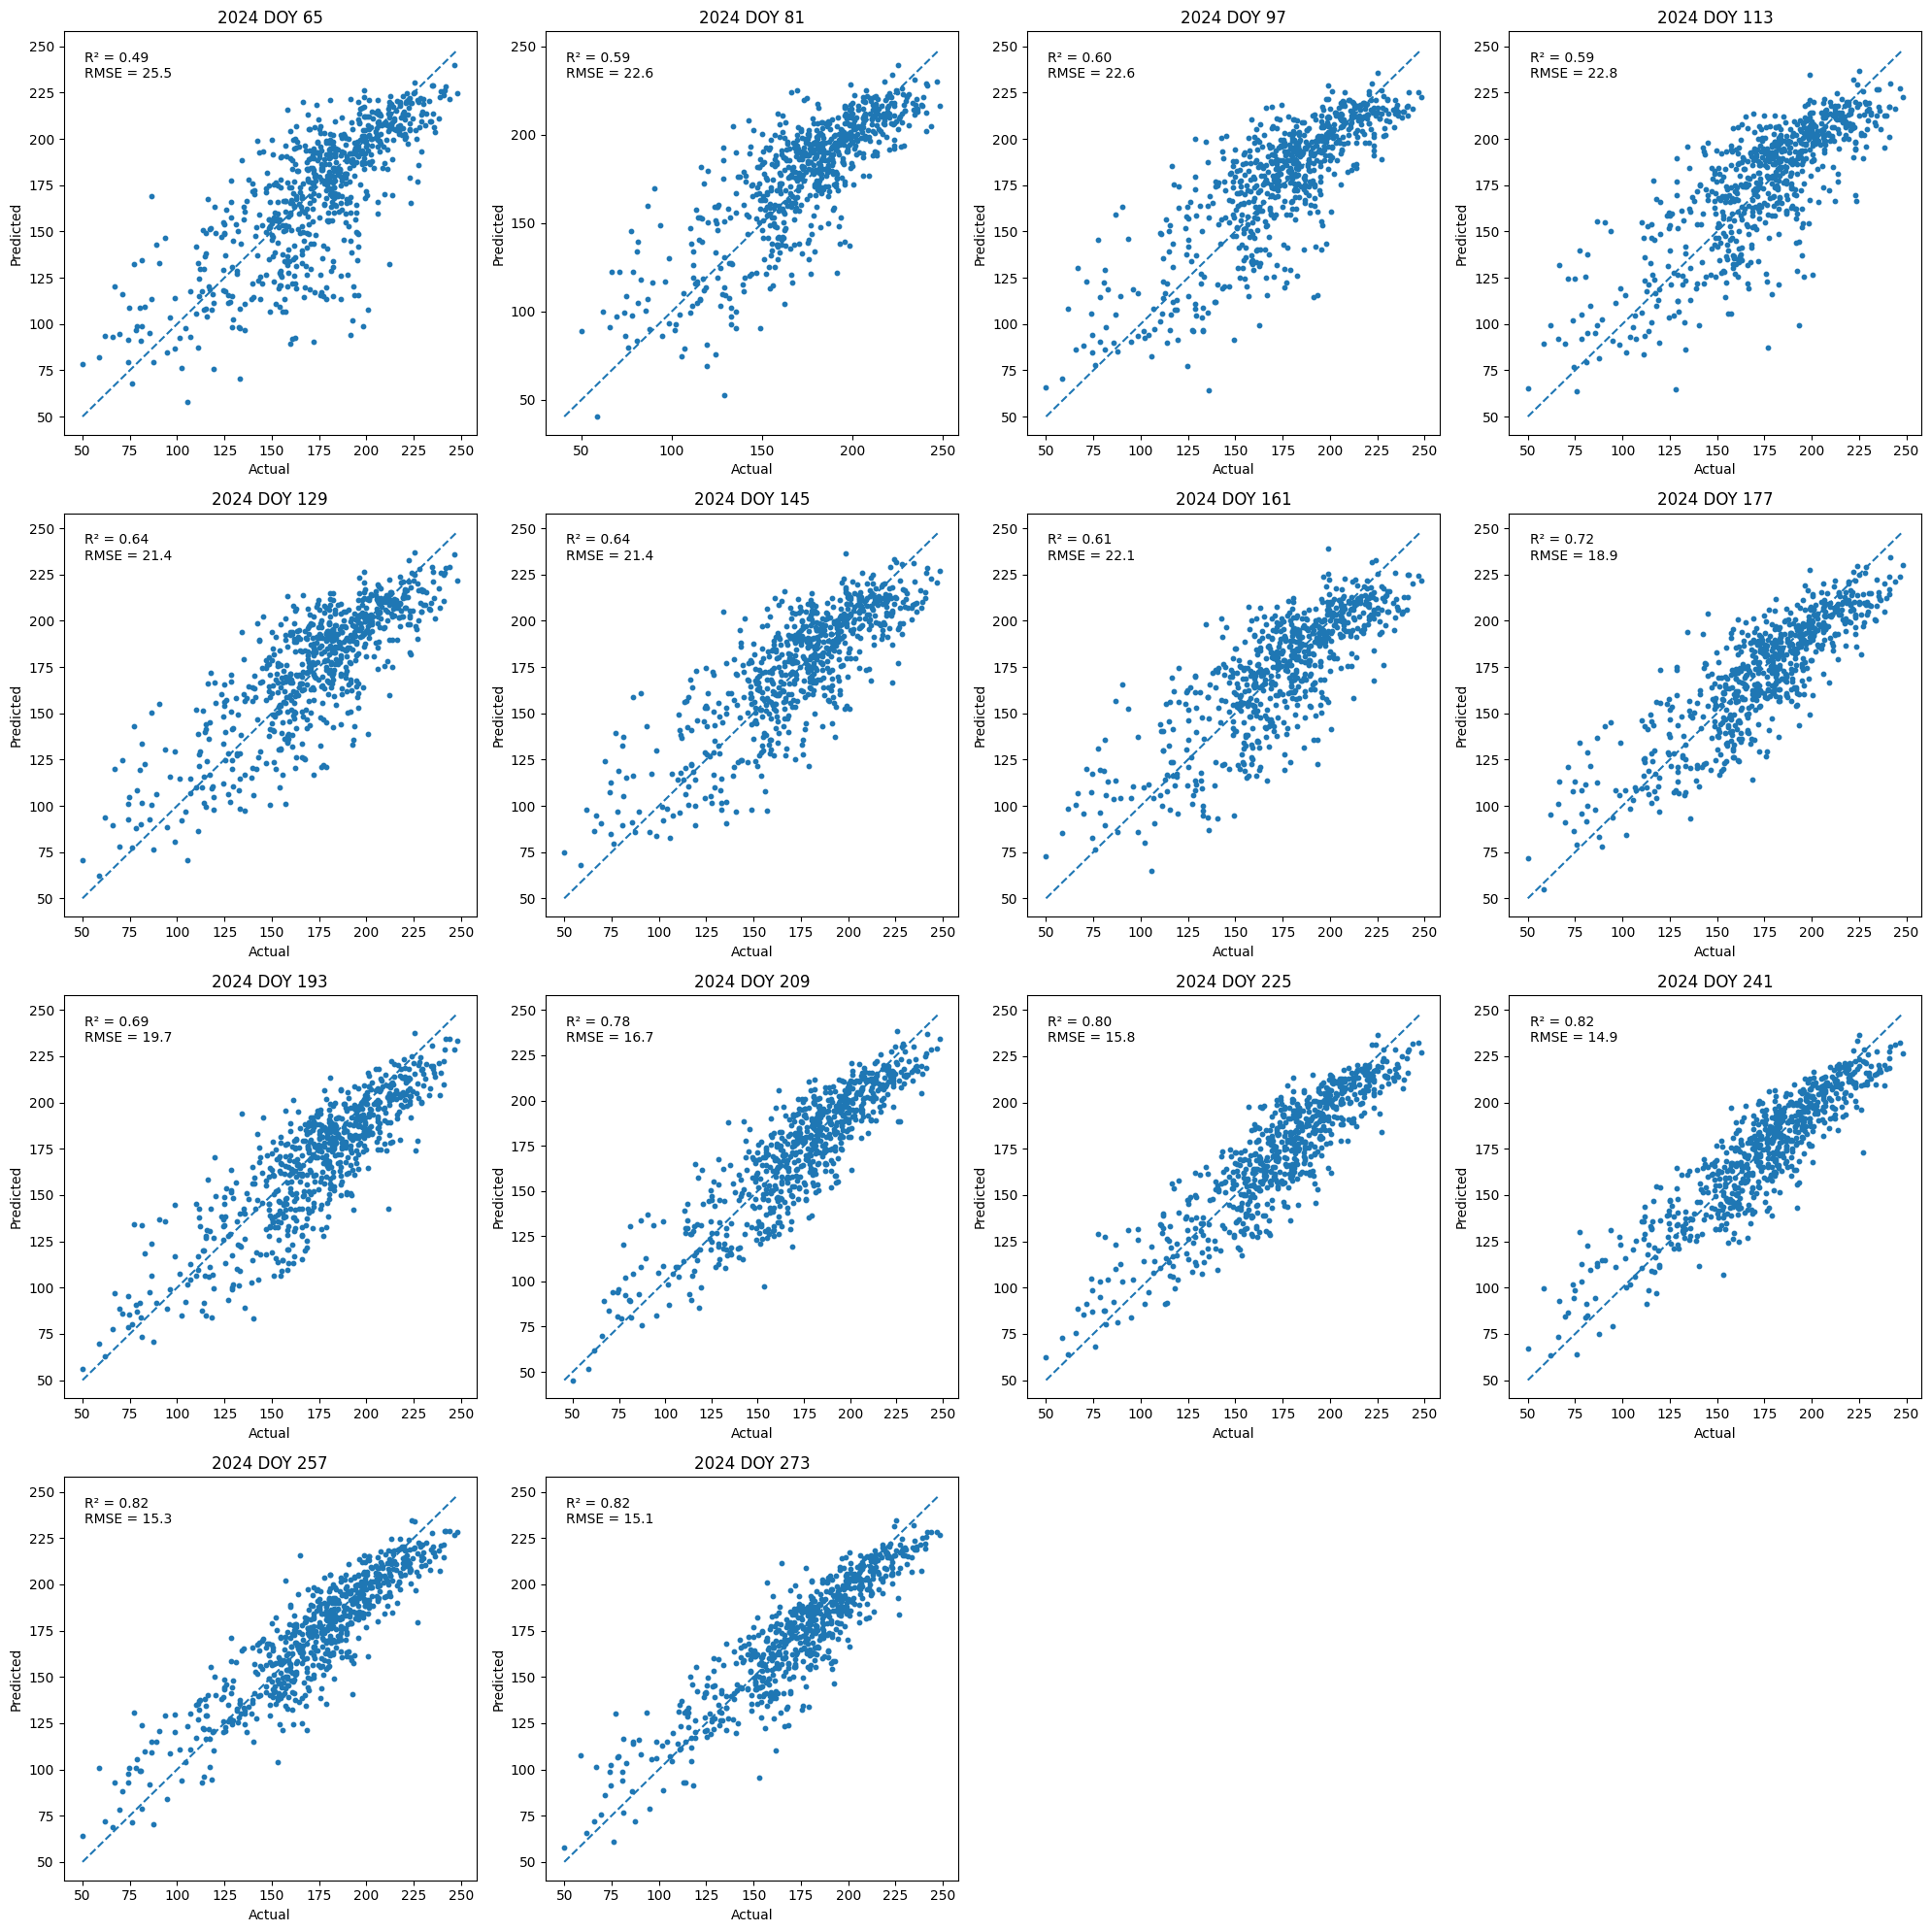

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

DOY_LIST = list(range(65, 275, 16))

ncols = 4
nrows = int(np.ceil(len(DOY_LIST) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()

for i, doy_cut in enumerate(DOY_LIST):

    ax = axes[i]

    # -----------------------------
    # TRAIN / TEST
    # -----------------------------
    train_df = df_prev_cdl[df_prev_cdl["year"] < TEST_YEAR].copy()
    test_df  = df_prev_cdl[df_prev_cdl["year"] == TEST_YEAR].copy()

    X_train = build_features(train_df, doy_cut)
    X_test  = build_features(test_df, doy_cut)

    if X_train.empty or X_test.empty:
        ax.axis("off")
        continue

    # -----------------------------
    # CLEAN FEATURES
    # -----------------------------
    X_train = X_train.drop(columns=[c for c in leakage_cols if c in X_train], errors="ignore")
    X_test  = X_test.drop(columns=[c for c in leakage_cols if c in X_test], errors="ignore")

    X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
    X_test["hist_5yr"]  = test_df.loc[X_test.index, "hist_5yr"]

    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)

    # -----------------------------
    # TARGET
    # -----------------------------
    y_train = (
        train_df.loc[X_train.index, "yield_filled"]
        - train_df.loc[X_train.index, "hist_5yr"]
    )

    y_test_actual = test_df.loc[X_test.index, "yield_bu_acre"].values

    # -----------------------------
    # MODEL
    # -----------------------------
    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_anomaly = model.predict(X_test)

    pred_yield = (
        test_df.loc[X_test.index, "hist_5yr"].values
        + pred_anomaly
    )

    # -----------------------------
    # METRICS
    # -----------------------------
    r2 = r2_score(y_test_actual, pred_yield)
    rmse = np.sqrt(mean_squared_error(y_test_actual, pred_yield))

    # -----------------------------
    # SCATTER PLOT
    # -----------------------------
    ax.scatter(y_test_actual, pred_yield, s=10)

    # 1:1 line
    min_val = min(y_test_actual.min(), pred_yield.min())
    max_val = max(y_test_actual.max(), pred_yield.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    # Labels
    ax.set_title(f"{TEST_YEAR} DOY {doy_cut}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

    # Metrics text (top-left like your image)
    ax.text(
        0.05, 0.95,
        f"R² = {r2:.2f}\nRMSE = {rmse:.1f}",
        transform=ax.transAxes,
        verticalalignment="top"
    )

# Remove empty plots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()